# Intuit Quickbooks Upgrade

* Team-lead GitHub userid: rsm-jal167 (person submitting)
* Group name: Team 4
* Team member names:
    - Melody Miu
    - Andrew Burda
    - Jay Lee
    - Juan Hernandez Guizar

In [1]:
import pandas as pd
import pyrsm as rsm
# from utils import functions
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
## loading the data - this dataset must NOT be changed
intuit75k = pd.read_parquet("data/intuit75k.parquet")


## Intuit: Quickbooks upgrade
The purpose of this exercise is to gain experience modeling the response to an upsell campaign. The intuit75k.parquet file contains data on 75,000 (small) businesses that were selected randomly from the 801,821 that were sent the wave-1 mailing. The mailing contained an offer to upgrade to the latest version of the Quickbooks software.

Variable res1 denotes which of these businesses responded to the mailing by purchasing Quickbooks version 3.0 from "Intuit Direct". Note that Intuit Direct sells products directly to its customers rather than through a retailer. Use the available data to predict which businesses that did not respond to the wave-1 mailing, are most likely to respond to the wave-2 mailing. Note that variables were added, deleted, and recoded so please ignore the variable descriptions in Exhibit 3 in the case pdf. Instead, use the variable descriptions below:

### Variable description
id: Small business customer ID

zip5: 5-Digit ZIP Code (00000=unknown, 99999=international ZIPs).

zip_bins: Zip-code bins (20 approx. equal sized bins from lowest to highest zip code number)

sex: Gender Identity "Female", "Male", or "Unknown"

bizflag: Business Flag. Address contains a Business name (1 = yes, 0 = no or unknown).

numords: Number of orders from Intuit Direct in the previous 36 months

dollars: Total $ ordered from Intuit Direct in the previous 36 months

last: Time (in months) since last order from Intuit Direct in previous 36 months

sincepurch: Time (in months) since original (not upgrade) purchase of Quickbooks

version1: Is 1 if customer's current Quickbooks is version 1, 0 if version 2

owntaxprod: Is 1 if customer purchased tax software, 0 otherwise
pgraded from Quickbooks vs. 1 to vs. 2

res1: Response to wave 1 mailing ("Yes" if responded else "No")

training: 70/30 split, 1 for training sample, 0 for test sample

In [3]:
intuit75k.head()

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0


### Based on the given hints, we decided to change the zip_bins into a categorical variable. Also, binary variables (version1, owntaxprod, upgraded) with data type as integer. 

In [4]:
# Convert selected columns to categorical
categorical_cols = ['zip_bins', 'bizflag', 'version1', 'owntaxprod', 'upgraded']
intuit75k[categorical_cols] = intuit75k[categorical_cols].astype('category')

/tmp/ipykernel_16300/6074509.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zip_bin_response_rate = intuit75k.groupby('zip_bins')['res1_yes'].mean().reset_index()
/tmp/ipykernel_16300/6074509.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zip_bin_response_rate['zip_bins'], y=zip_bin_response_rate['res1_yes'], palette="Blues_r")


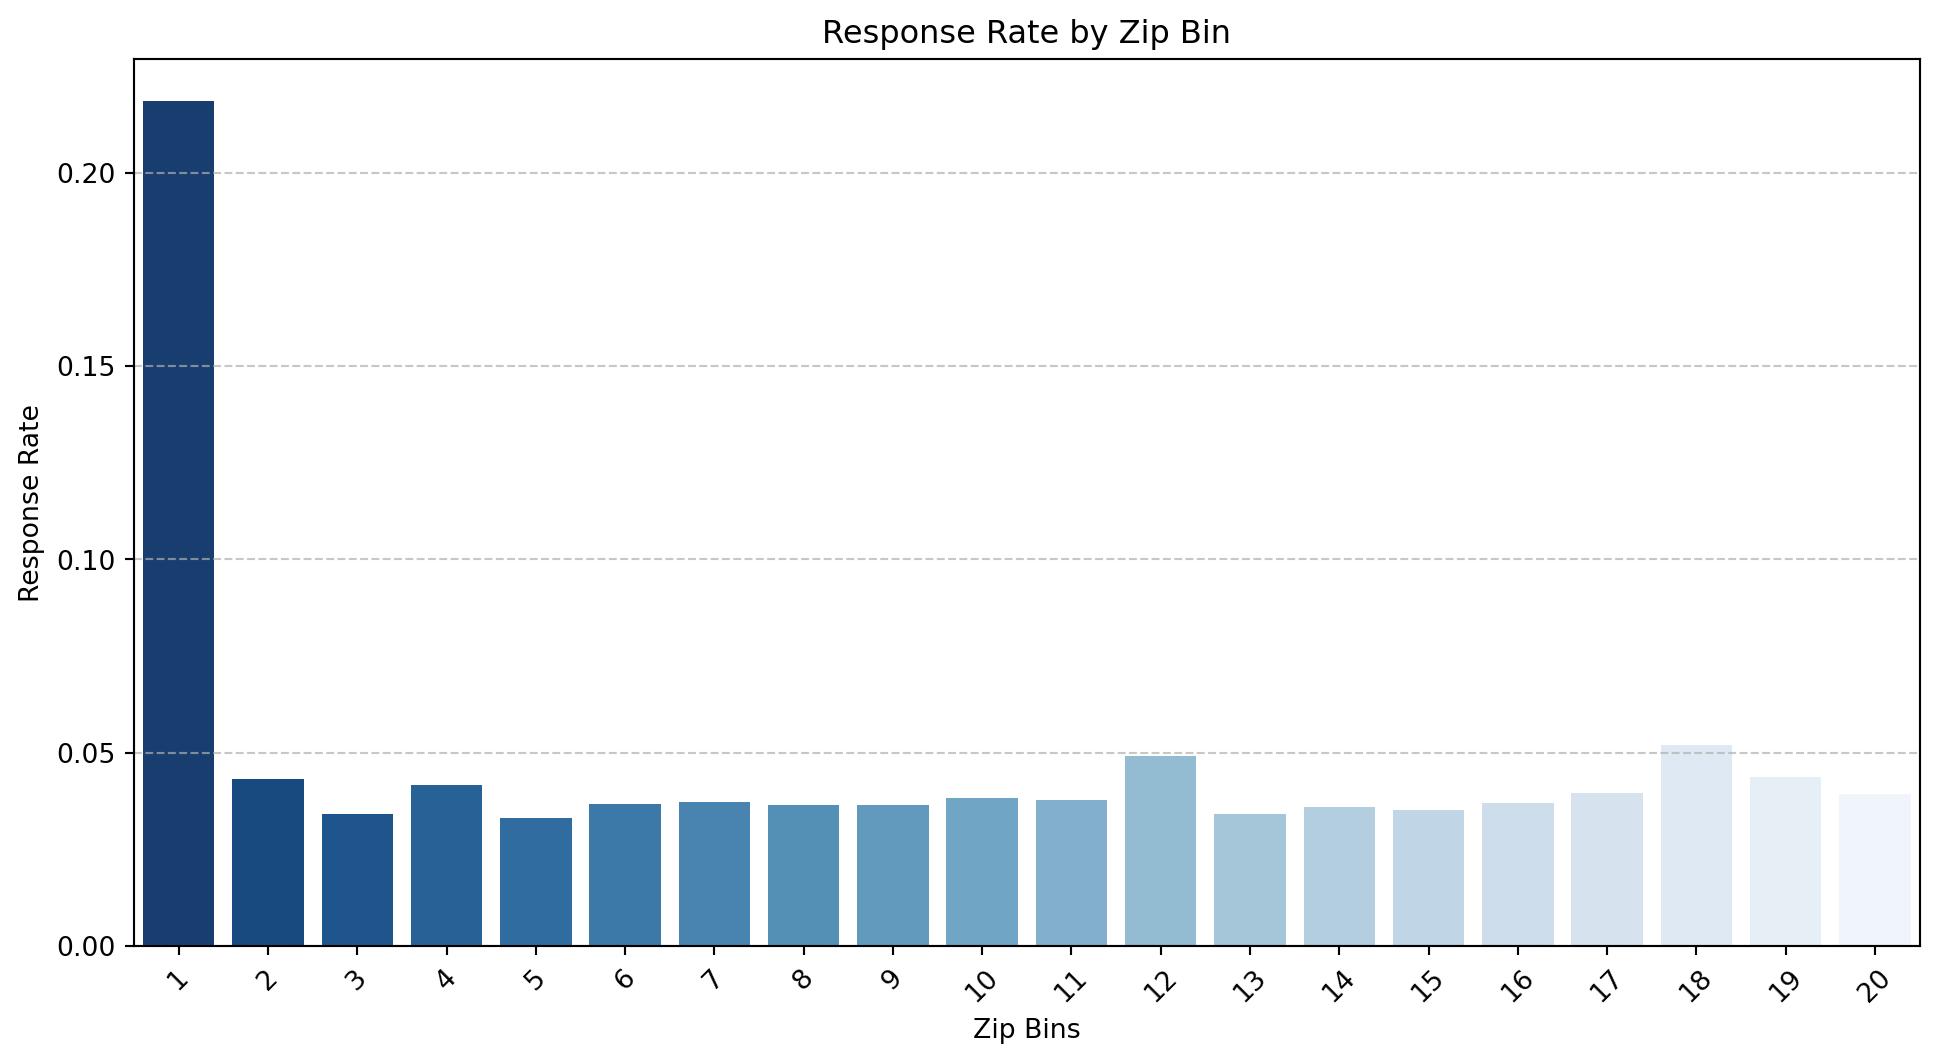

In [5]:
# Group by zip_bins and calculate the mean response rate
zip_bin_response_rate = intuit75k.groupby('zip_bins')['res1_yes'].mean().reset_index()


# Plot the response rate by zip bins
plt.figure(figsize=(12, 6))
sns.barplot(x=zip_bin_response_rate['zip_bins'], y=zip_bin_response_rate['res1_yes'], palette="Blues_r")

# Formatting the plot
plt.xlabel("Zip Bins")
plt.ylabel("Response Rate")
plt.title("Response Rate by Zip Bin")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

In [6]:
zip_bins_1 = intuit75k[intuit75k['zip_bins' ]== 1]

print(zip_bins_1)

          id   zip5 zip_bins     sex bizflag  numords  dollars  last  \
3          4  02125        1    Male       0        1     22.0    17   
21        22  00801        1    Male       1        4    116.5     6   
81        82  00801        1    Male       0        1     29.5    22   
129      130  00801        1  Female       0        1      9.5     4   
138      139  01803        1    Male       0        2     79.0     3   
...      ...    ...      ...     ...     ...      ...      ...   ...   
74848  74849  00000        1    Male       0        3    178.5    34   
74858  74859  02138        1    Male       1        2     71.5    21   
74915  74916  00911        1    Male       1        1     14.5    11   
74929  74930  01907        1    Male       1        2     85.5    26   
74988  74989  00801        1    Male       0        1     53.5     4   

       sincepurch version1 owntaxprod upgraded res1  training  res1_yes  
3               1        0          0        0   No         1

In [7]:
# Filter for ZIP code 00801
zip_00801_data = intuit75k[intuit75k['zip5'] == '00801']

# Count occurrences of each bizflag value
bizflag_counts = zip_00801_data['bizflag'].value_counts()

print(bizflag_counts)

bizflag
0    1225
1     443
Name: count, dtype: int64


`zip_bins` : Certain zip bins (e.g., Bin 1, Bin 12, Bin 18) have higher response rates. Zip bins may indicate regional factors that influence purchasing behavior like cities may be more likely to upgrade than small towns. This suggests that zip_bins is a strong predictive feature and should be included in the model.

In this graph, we can see that zip_bin 1 has the highest response rate over 0.2. Zip_bins 12 and 18 have the next highest response rate at 0.05. Looking at the zipcodes in zip_bin 1, it is noteable that 44% of the responses came from the zip code 00801. This is in the Virgin Islands, which is a US territory, not on the mainland. Although the Virgin Islands are commonly associated with businesses, the majority of transactions in this dataset (1,225) came from non-business customers `bizflag = 0`, compared to only 443 transactions from business customers `bizflag = 1`. This is somewhat unexpected given the location’s reputation for business activity


`Sex`: Gender is split about 60 / 30 / 10 for male / female / unknown respectively. Hinting that gender is a variable to account for. Historically there has been a larger pool of software customers that are male as opposed to other gender, aligning with our preliminary results. If male/female business owners behave differently, this might be a significant interaction with bizflag.

`Bizflag`: Businesses generally have more capital to spend than individual users. Thus we would expect businesses to spend more money and be more likely to upgrade or a regular cadence.

`Numords`: More past orders indicate a higher likelihood of responding. This may be due to higher engagement and more engagement may mean more likely to be a repeat customer.

`Version1`: Customers on version 1 may need an upgrade more than version 2 users as their software is more outdated. The version1 user may have a higher response rate than version 2 as it is older.

`Owntaxprod`: If the user has previously purchased the software, they are likely to purchase more in the future. Customers using tax products might be loyal to Intuit, leading to higher upgrade likelihood.

`Sincepurch`: This variable represents the time since the customer originally purchased Quickbooks. This is a key predictor of response likelihood because it reflects customer lifecycle and engagement Customers who purchased a long time ago may be due for an upgrade.Older customers may either be loyal users or satisfied non-upgraders. 

`Upgraded`: Customers who have upgraded their software before are more likely to do so again. They might be willing to upgrade to a newer version as they are familiar with the software and may be loyal to it 

`Last`: Customers who have purchased recently or at a regular cadence are more likely to purchase again than those who have not purchased in a while. We saw this trend with our previous case studies and thus expect it to hold true here as well (at least until disproved).

In [8]:
#functions.example()

In [9]:
# show the content of another notebook
#rsm.md_notebook("sub-notebooks/question1.ipynb")

In [10]:
# run python code from another notebook
#%run ./sub-notebooks/question1.ipynb

### Baseline Model

We first developed a baseline model incorporating all relevant variables to establish an initial point of reference. This provided an overview of how each factor might contribute to the outcome before making any refinements or applying more advanced techniques.

In [11]:
#Start by creating a model with all the variables

intuit75k_model_v1 = rsm.model.logistic(
    data=intuit75k.query("training == 1"),
    rvar="res1",
    lev="Yes",
    evar=["sex","bizflag","numords", 'last', 'sincepurch', 'owntaxprod', 'dollars',  "version1", "upgraded", "zip_bins"],
)
intuit75k_model_v1.summary(vif = True)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: sex, bizflag, numords, last, sincepurch, owntaxprod, dollars, version1, upgraded, zip_bins
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                  OR     OR%  coefficient  std.error  z.value p.value     
Intercept      0.181  -81.9%        -1.71      0.092  -18.507  < .001  ***
sex[Male]      0.975   -2.5%        -0.03      0.053   -0.472   0.637     
sex[Unknown]   0.964   -3.6%        -0.04      0.076   -0.485   0.628     
bizflag[1]     1.036    3.6%         0.04      0.049    0.728   0.466     
owntaxprod[1]  1.356   35.6%         0.30      0.103    2.959   0.003   **
version1[1]    2.113  111.3%         0.75      0.087    8.583  < .001  ***
upgraded[1]    2.616  161.6%         0.96      0.086   11.201  < .001  ***
zip_bins[2]    0.148  -85.2%        -1.91      0.110  -17.296  < .001  ***
zip_bin


              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000


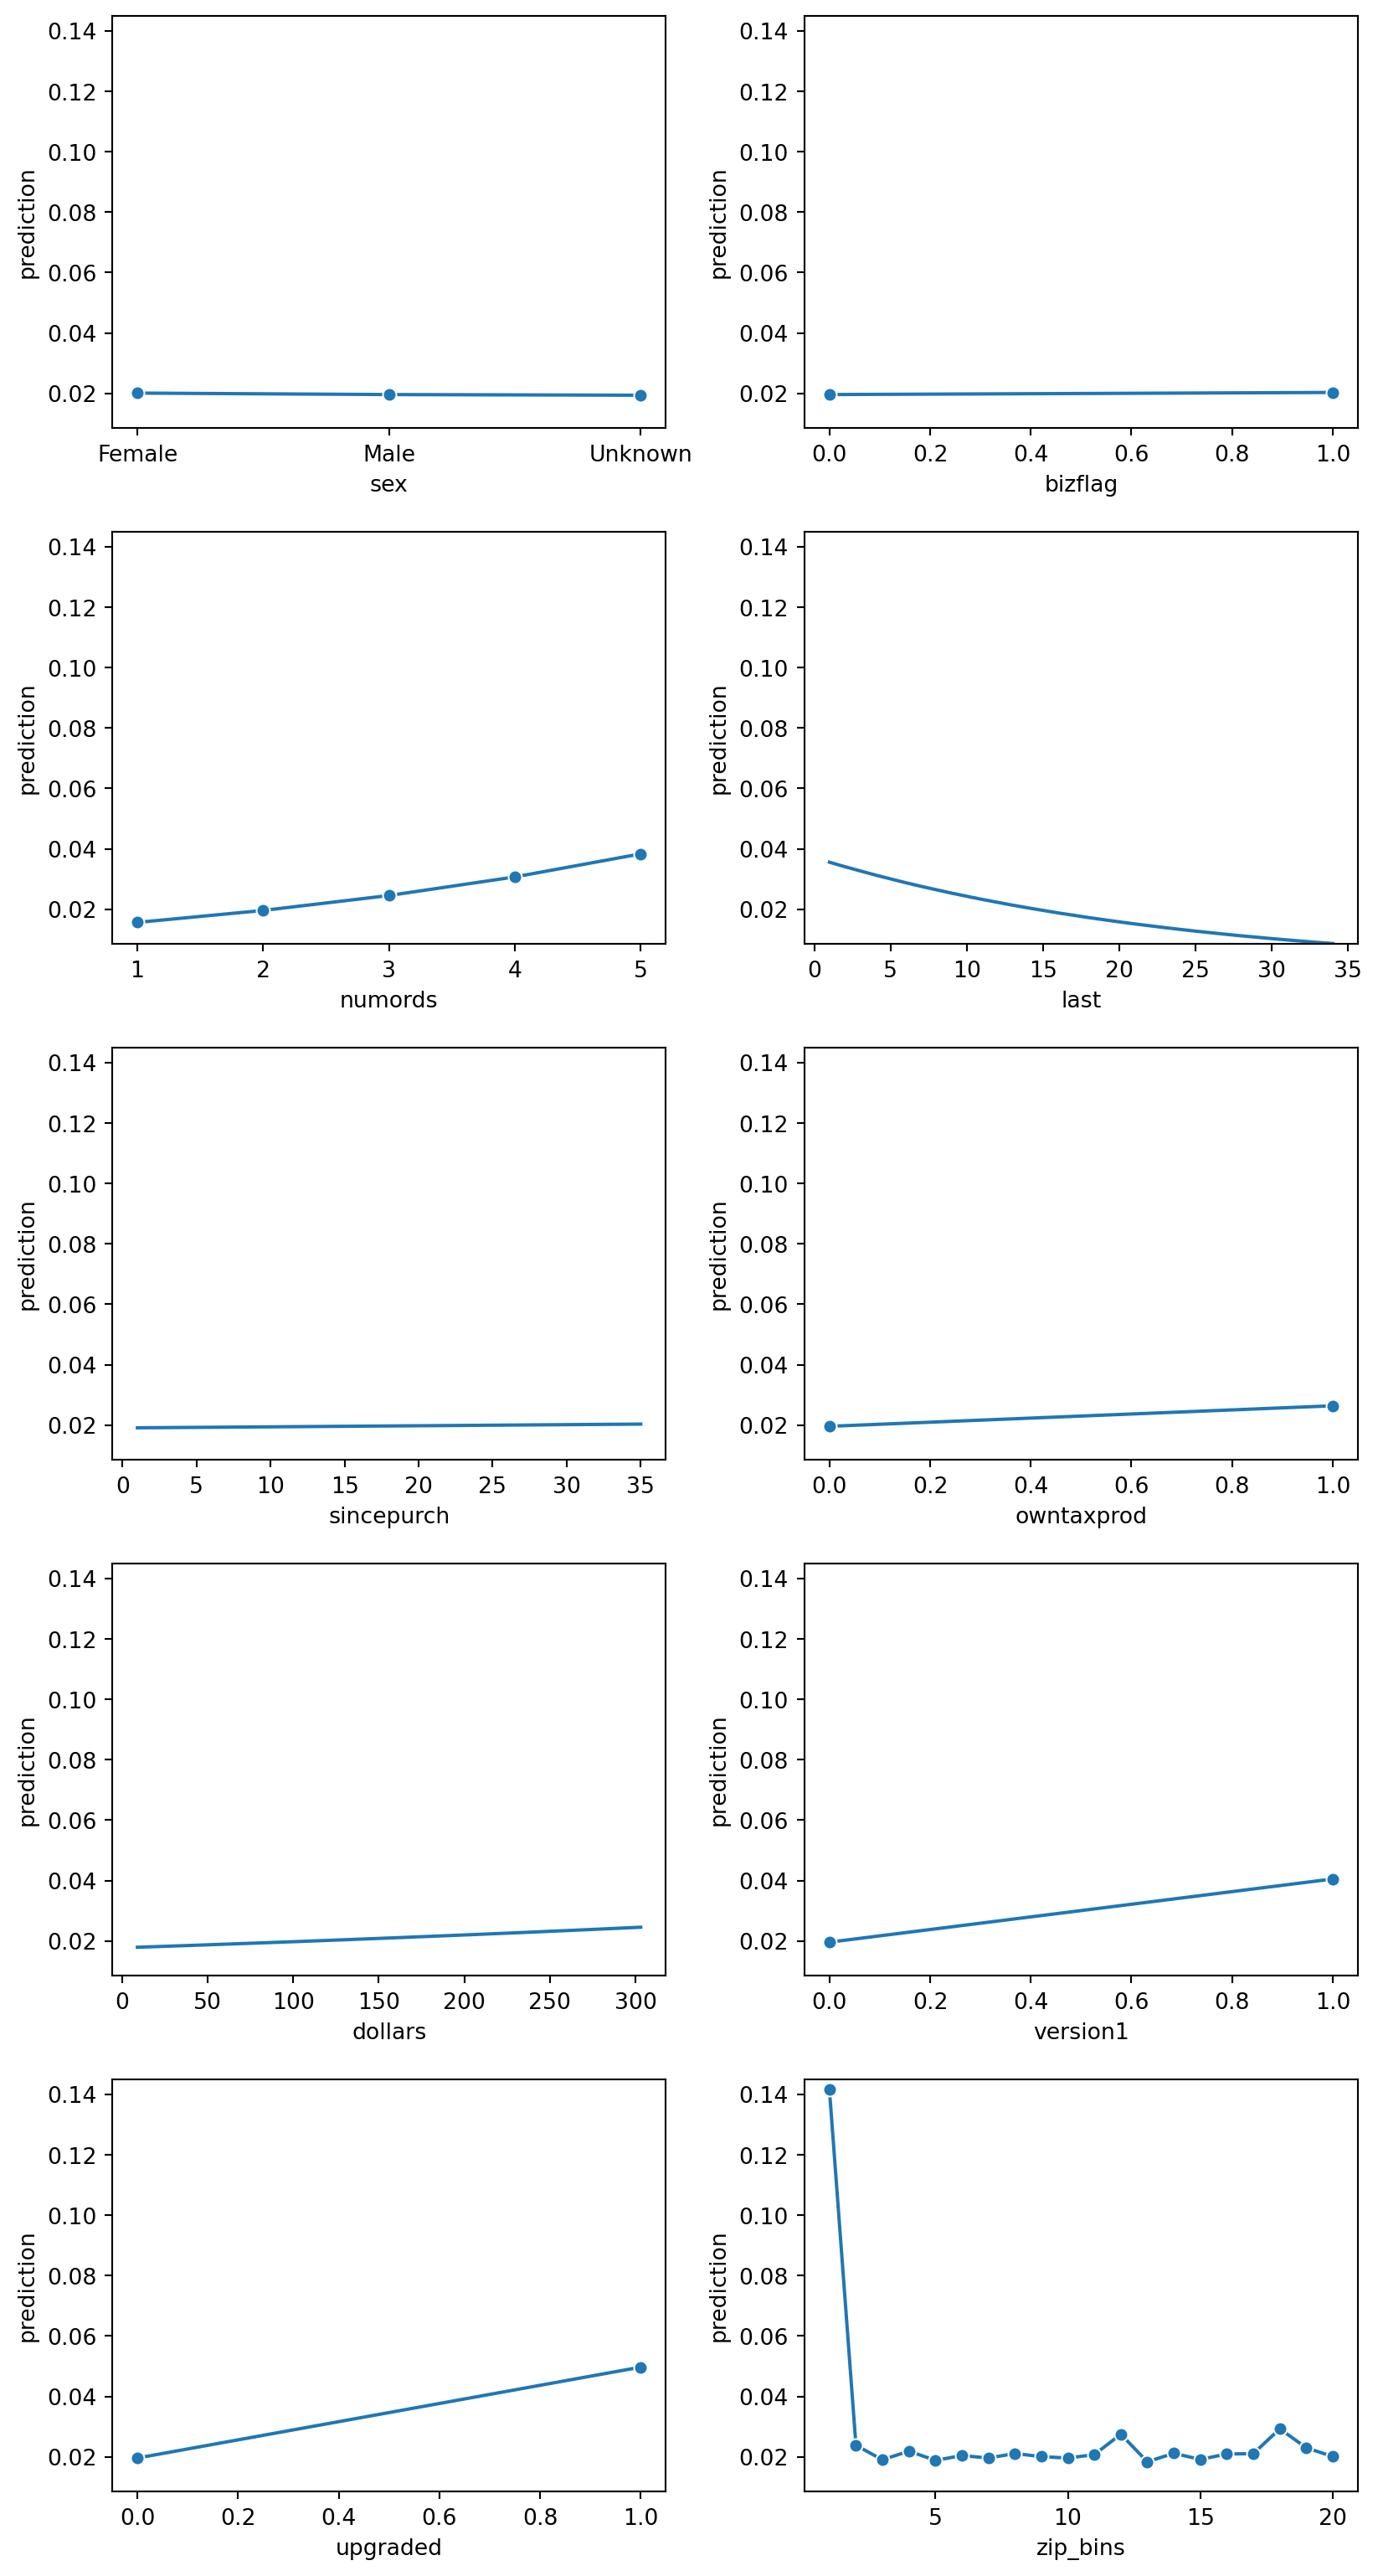

In [12]:
intuit75k_model_v1.plot("pred")

`Sex`: The predicted outcome remains relatively flat across Female, Male, and Unknown categories, indicating that gender does not significantly impact predictions.

`Bizflag`: Predictions appear nearly identical between business (1) and non-business (0) customers, suggesting that business status has minimal influence on the outcome. Regardless of business status it has equal predicting power. (.02)

`Number of Orders` ("numords"): There is a positive trend—higher numbers of orders correspond with increased predictions, implying that order frequency is an important factor.

`Recency of Last Purchase` ("last"): Predictions decrease as the time since the last purchase increases, indicating that recent purchasers are more likely to exhibit the predicted behavior.

`Months Since First Purchase` ("sincepurch"): Predictions remain mostly flat, suggesting that the time since the first purchase does not have a significant impact.

`Owns Tax Product` ("owntaxprod"): There is a slight upward trend, implying that customers who own a tax product are marginally more likely to exhibit the predicted behavior.

`dollars`: There is a slight upward trend, indicating that as the amount spent increases, the prediction value also increases. However, the effect appears minimal, suggesting that while spending more may slightly impact the outcome, it is not a strong predictor.

`Version1`: Predictions show a slight upward trend, meaning customers using this version of the product have a marginally higher likelihood of the predicted outcome.

`Upgraded`: Predictions increase more noticeably when a customer has upgraded, suggesting that upgrades are a strong indicator of the predicted behavior.

`Zip Bins`: (Bottom-left): There is a sharp drop from the first zip bin, which has a significantly higher predicted probability, followed by relatively stable but fluctuating values across the remaining bins. This suggests that certain zip code groups have a much stronger influence on predictions than others.

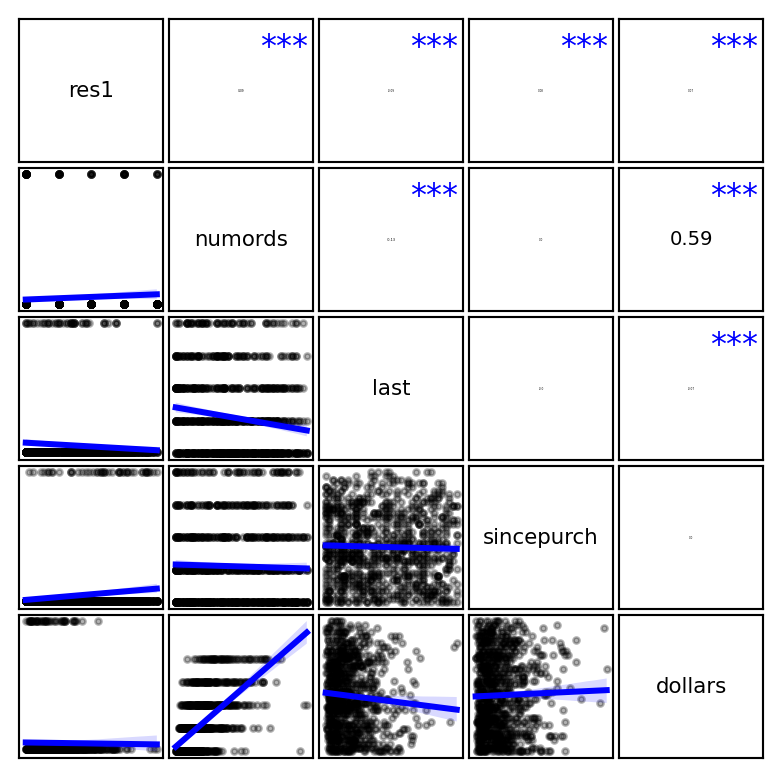

In [13]:
intuit75k_model_v1.plot('corr')

This correlation plot visualizes the relationships between different variables using scatter plots and correlation coefficients. The blue trend lines indicate general relationships between variables, while correlation values (e.g., 0.59) highlight stronger associations. Notable observations include:

`numords` and `dollars` show a positive relationship, meaning customers who place more orders tend to spend more.
`last` and `sincepurch` have a negative trend, indicating that as time since the last purchase increases, recency of purchase decreases (which makes intuitive sense).
Some variables, like `res1` do not appear to have strong linear relationships with others. We should also not that since we have categorical variables those don't show up in the plot. 

All VIF values are below 5, with most being close to 1, suggesting low correlation among independent variables. The highest VIF value is 3.737 for `sincepurch`, which is still within an acceptable range.

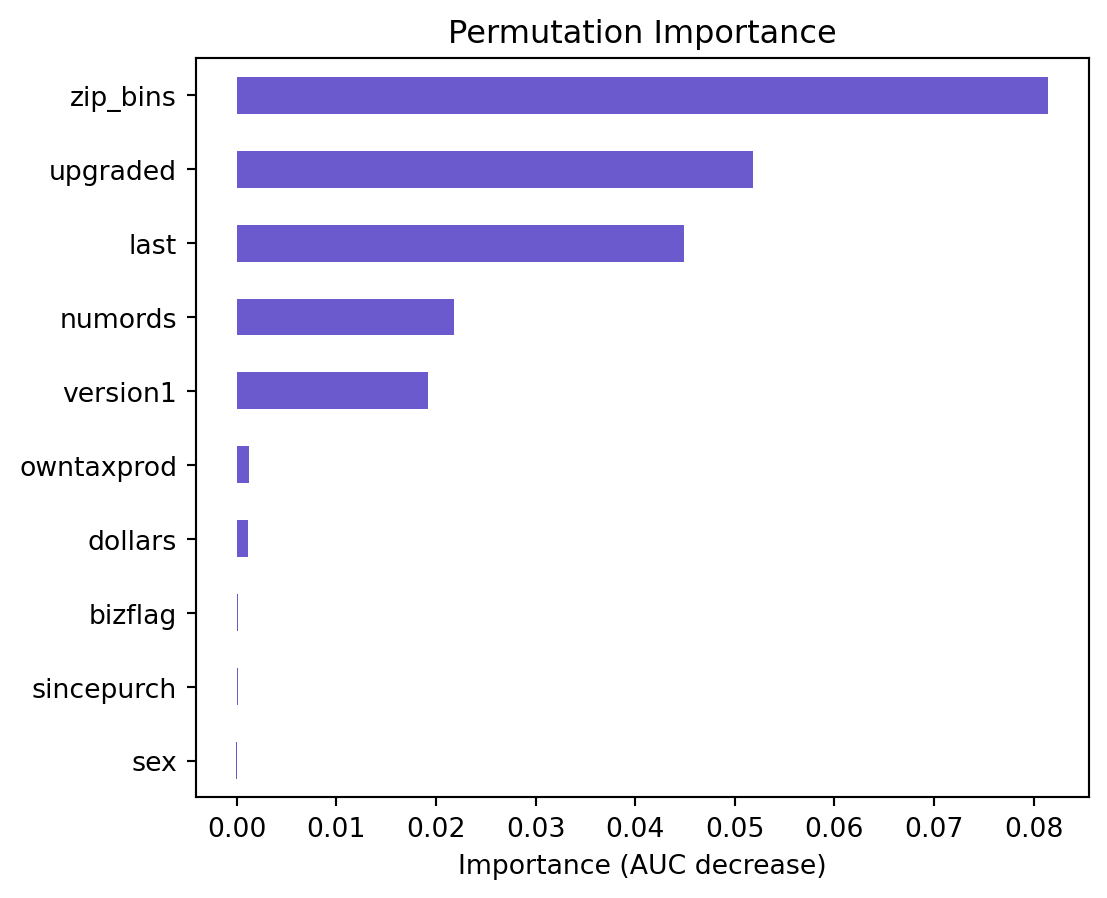

In [14]:
intuit75k_model_v1.plot("vimp")

This permutation importance plot shows how much each variable contributes to the model’s predictive performance. Zip bins have the highest importance, meaning geographic location plays the most significant role. Upgraded, last purchase recency , and number of orders are also key factors. Meanwhile, `dollars`, `owntaxprod`, `bizflag`, `sincepurch`, and `sex` have little to no impact on predictions

### Testing different model without dollar, bizflag, sincepurch, sex as they are not significant. Also, permutation importance shows that those variables are not important. 


In [15]:
intuit75k_model_v2 = rsm.model.logistic(
    data=intuit75k.query("training == 1"),
    rvar="res1",
    lev="Yes",
    evar=["numords", 'last', 'owntaxprod',  "version1", "upgraded", "zip_bins"],
)
intuit75k_model_v2.summary()

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: numords, last, owntaxprod, version1, upgraded, zip_bins
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                  OR     OR%  coefficient  std.error  z.value p.value     
Intercept      0.184  -81.6%        -1.69      0.075  -22.580  < .001  ***
owntaxprod[1]  1.364   36.4%         0.31      0.103    3.023   0.003   **
version1[1]    2.182  118.2%         0.78      0.053   14.815  < .001  ***
upgraded[1]    2.697  169.7%         0.99      0.051   19.575  < .001  ***
zip_bins[2]    0.148  -85.2%        -1.91      0.110  -17.296  < .001  ***
zip_bins[3]    0.118  -88.2%        -2.14      0.121  -17.679  < .001  ***
zip_bins[4]    0.137  -86.3%        -1.99      0.112  -17.766  < .001  ***
zip_bins[5]    0.117  -88.3%        -2.14      0.120  -17.835  < .001  ***
zip_bins[6]    0.127  -87.3%        -2.06 

### After taking out the variables dollar, bizflag, sincepurch, sex we noticed that the R-squared value decreased an insignificant amount. 
#### (0.114 -> 0.113)

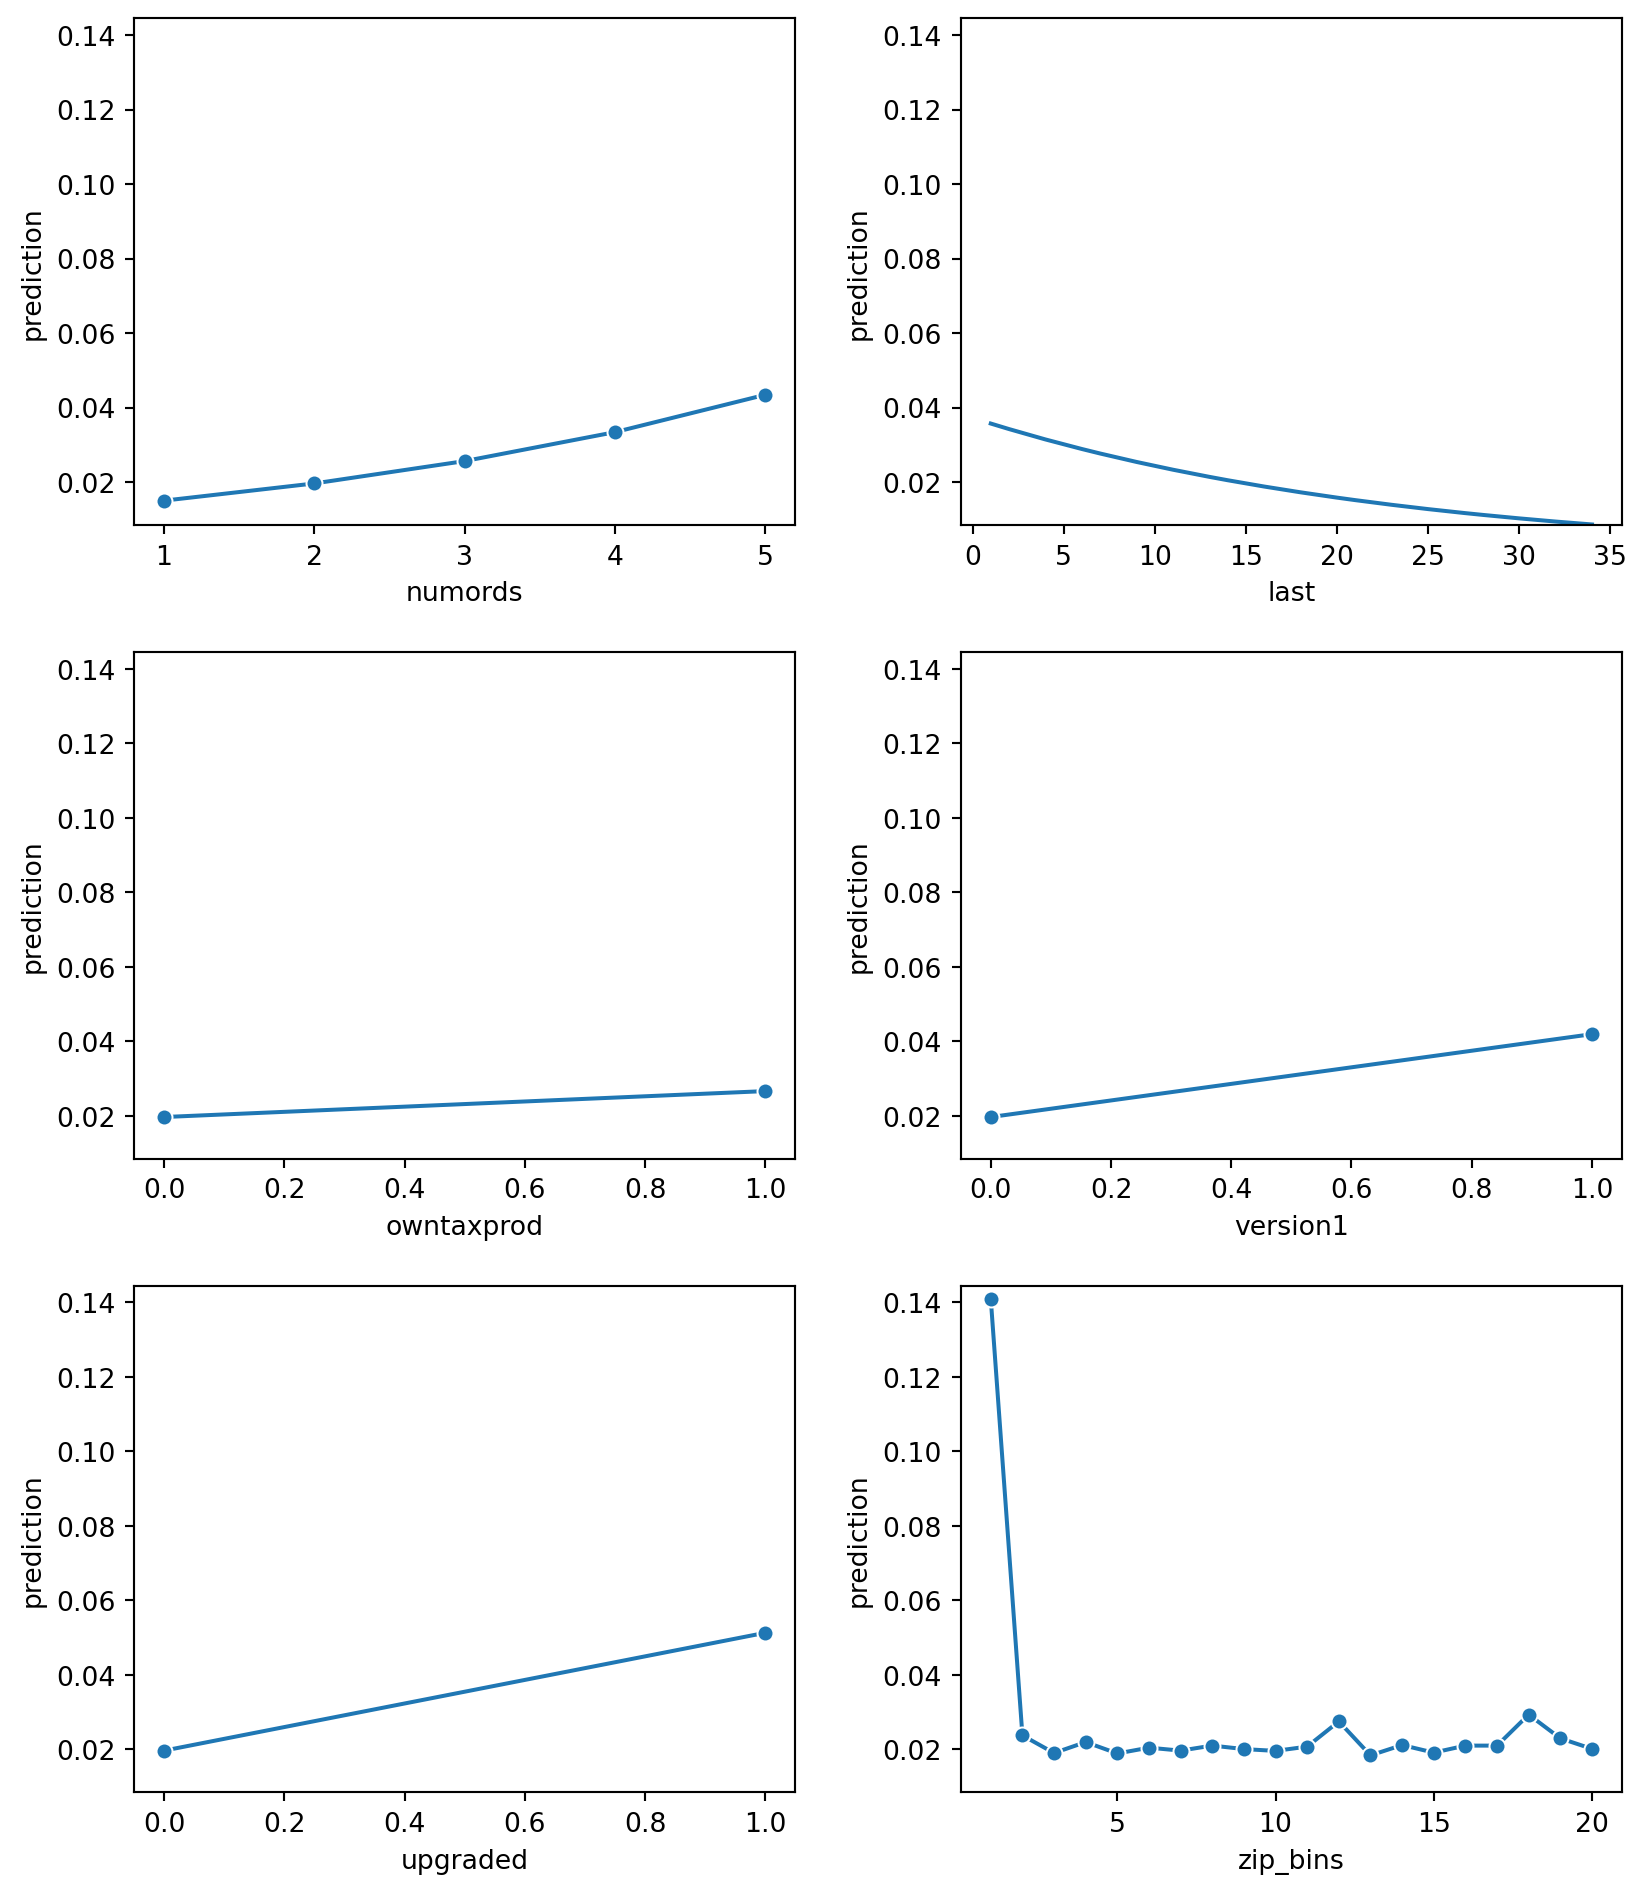

In [16]:
intuit75k_model_v2.plot("pred")

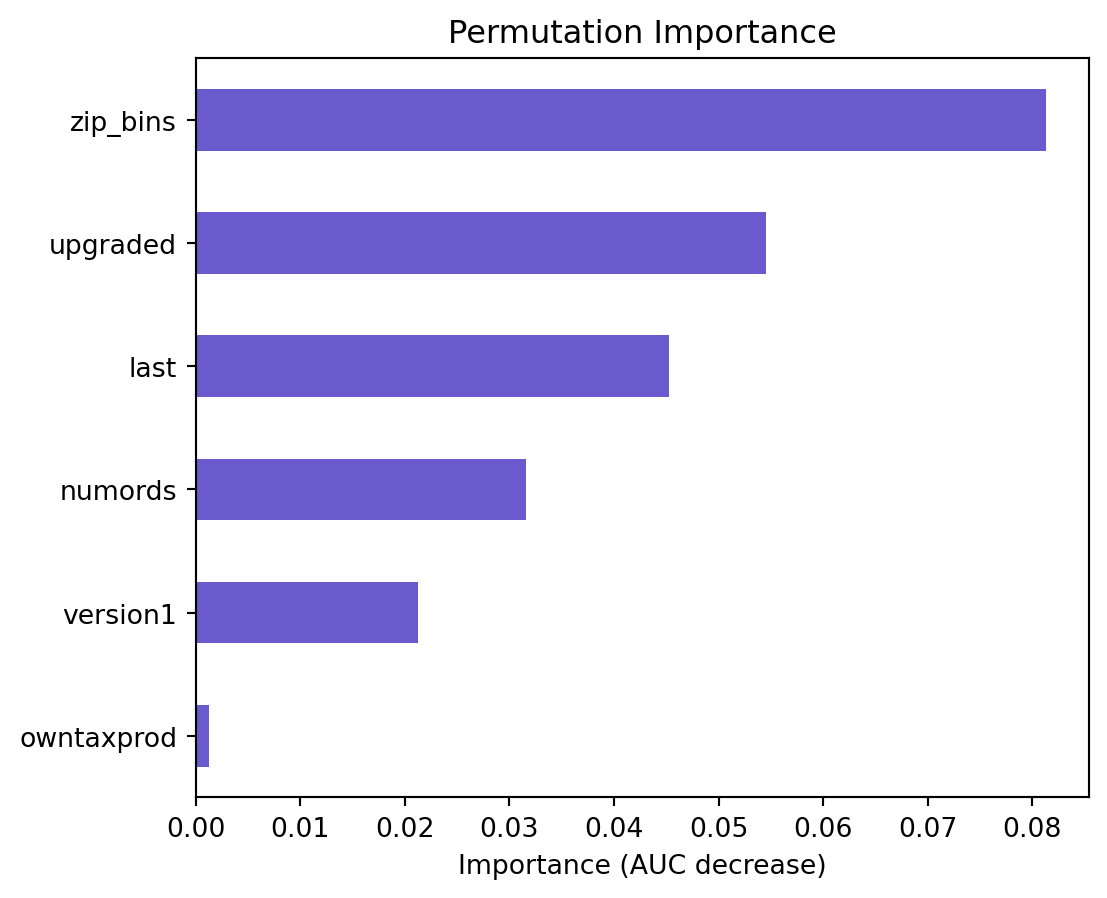

In [17]:
intuit75k_model_v2.plot("vimp") 

### We want to see if we can improve the model by dropping the owntaxprod since it is not important in the model.

In [18]:
intuit75k_model_v3 = rsm.model.logistic(
    data=intuit75k.query("training == 1"),
    rvar="res1",
    lev="Yes",
    evar=["numords", 'last',  "version1", "upgraded", "zip_bins"],
)
intuit75k_model_v3.summary()

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: numords, last, version1, upgraded, zip_bins
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                 OR     OR%  coefficient  std.error  z.value p.value     
Intercept     0.184  -81.6%        -1.69      0.075  -22.578  < .001  ***
version1[1]   2.157  115.7%         0.77      0.052   14.645  < .001  ***
upgraded[1]   2.731  173.1%         1.00      0.050   19.902  < .001  ***
zip_bins[2]   0.148  -85.2%        -1.91      0.110  -17.315  < .001  ***
zip_bins[3]   0.118  -88.2%        -2.14      0.121  -17.691  < .001  ***
zip_bins[4]   0.137  -86.3%        -1.99      0.112  -17.766  < .001  ***
zip_bins[5]   0.117  -88.3%        -2.14      0.120  -17.849  < .001  ***
zip_bins[6]   0.127  -87.3%        -2.06      0.114  -18.013  < .001  ***
zip_bins[7]   0.123  -87.7%        -2.10      0.117  -17.910  <

As you can see, dropping `owntaxprod` does not make a significant difference. 

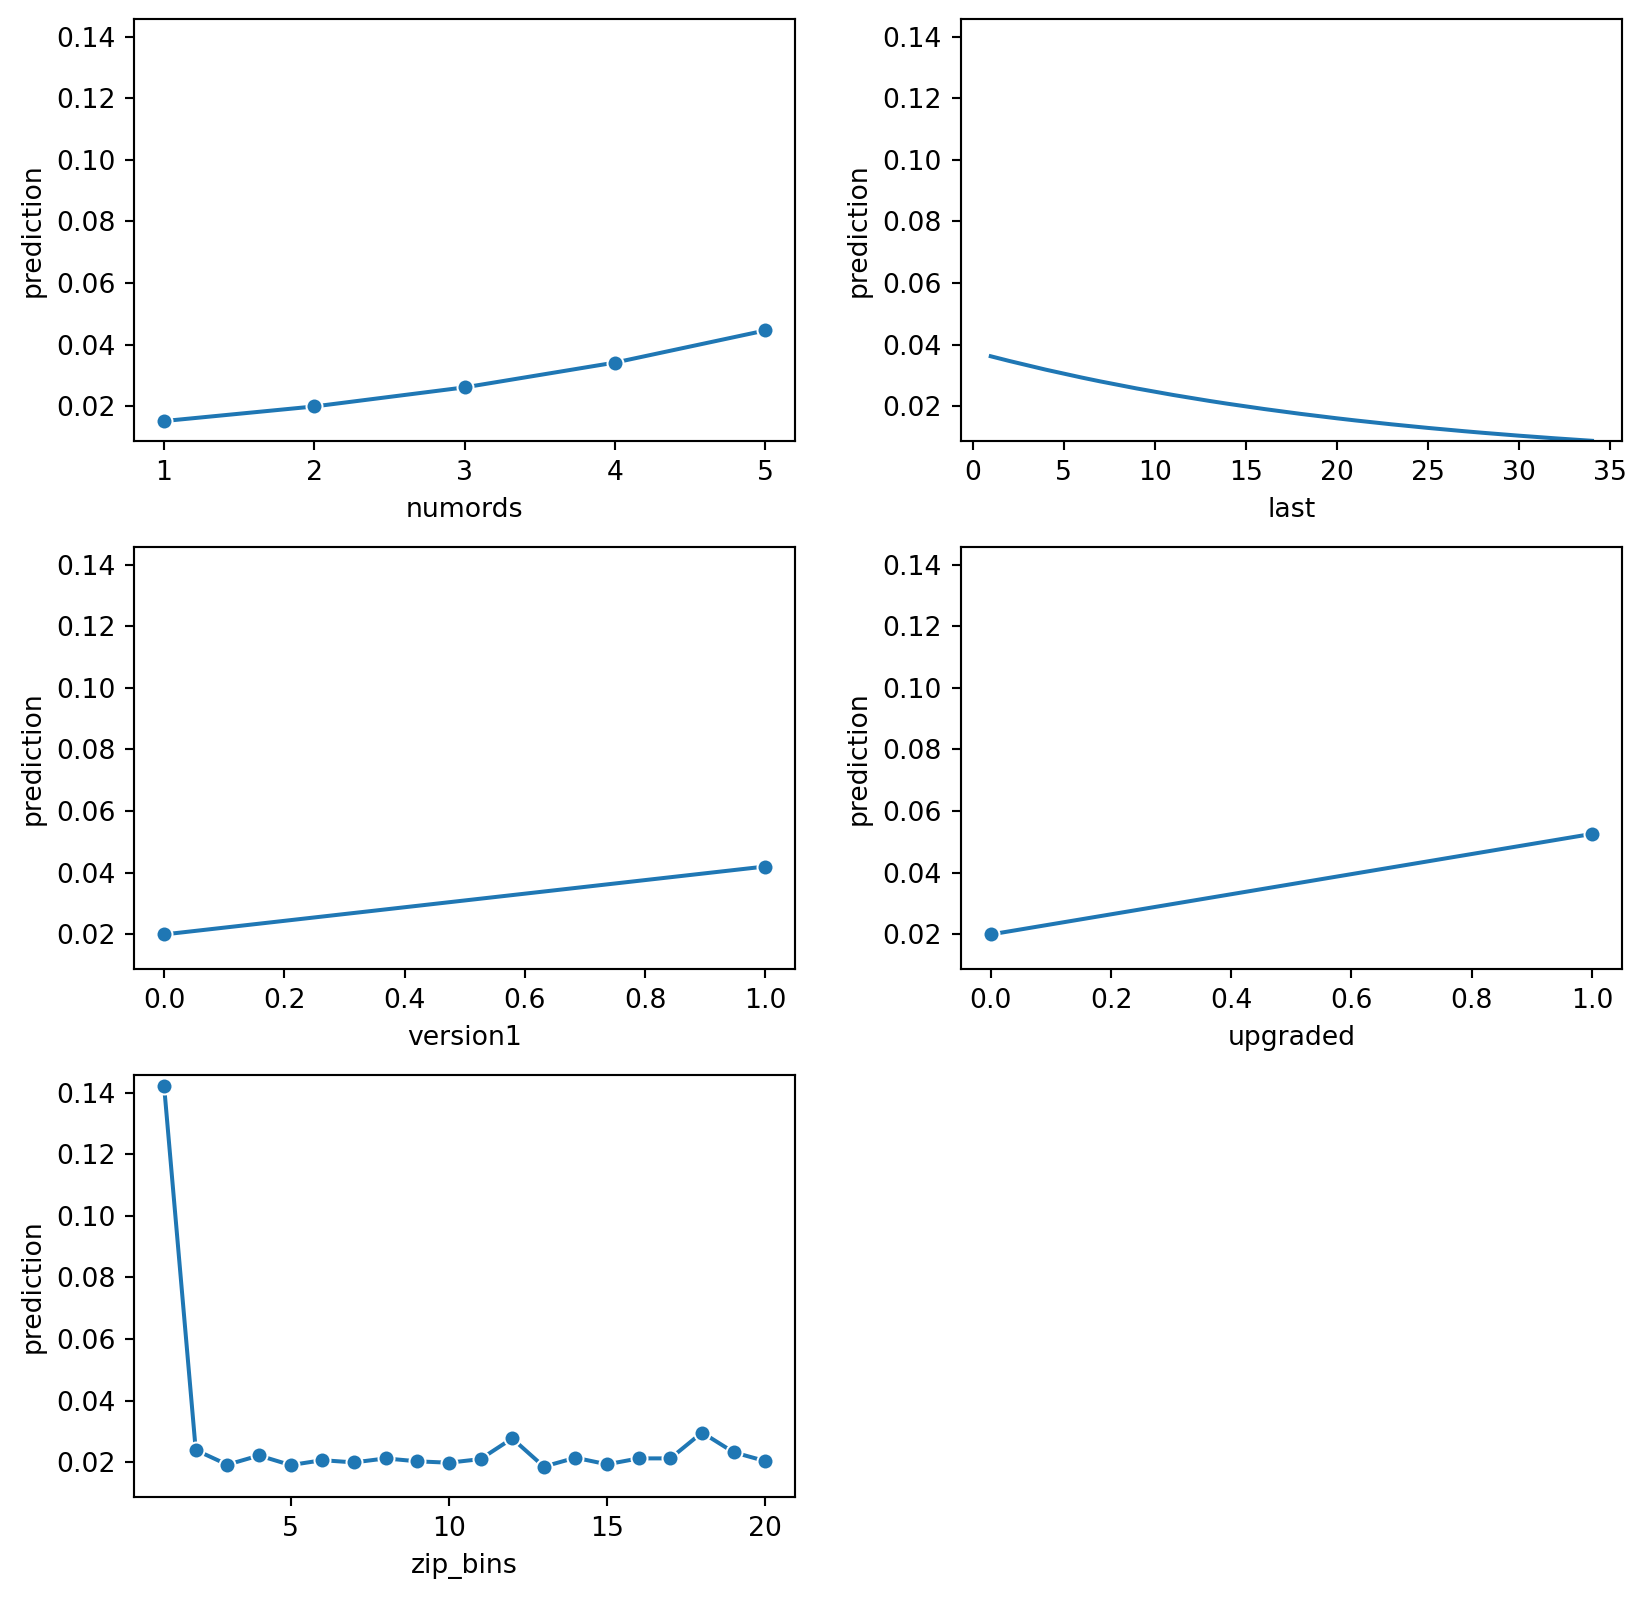

In [19]:
intuit75k_model_v3.plot("pred")

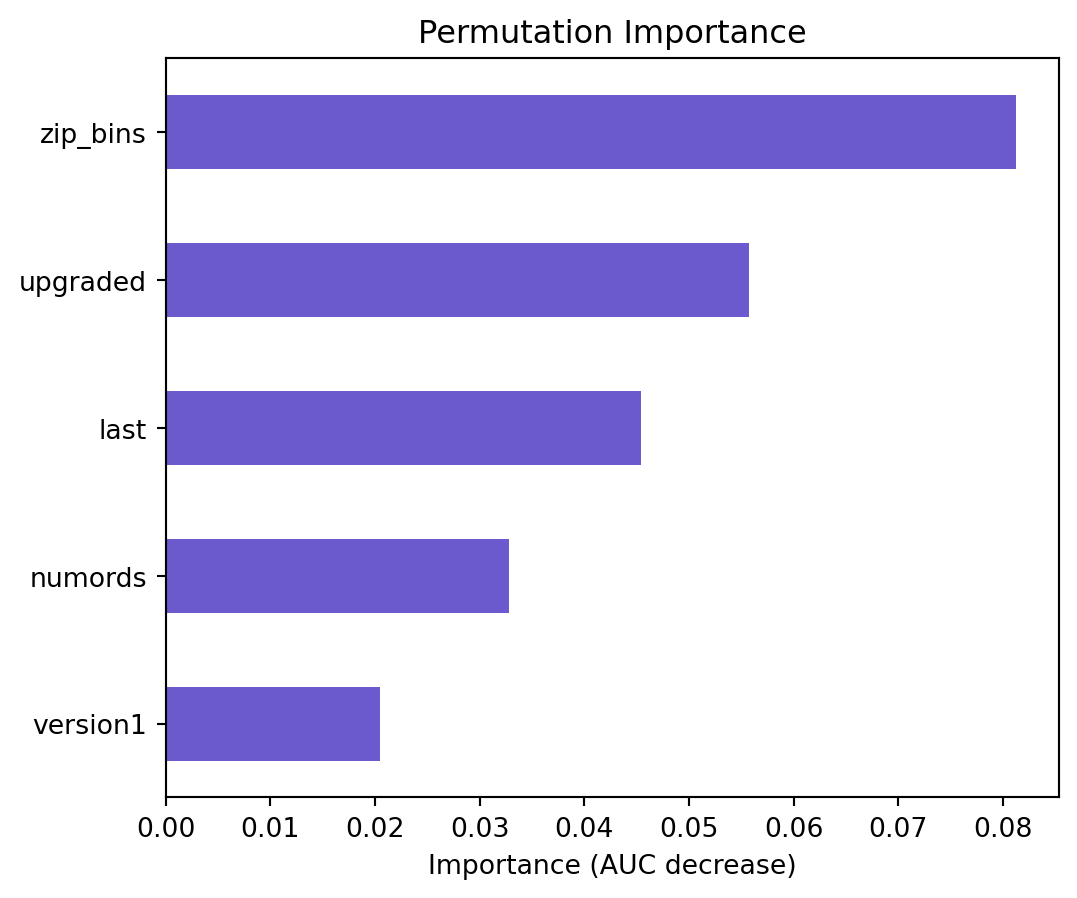

In [20]:
intuit75k_model_v3.plot("vimp")

### Checking correlation between variables to see if we can remove any more variables.  

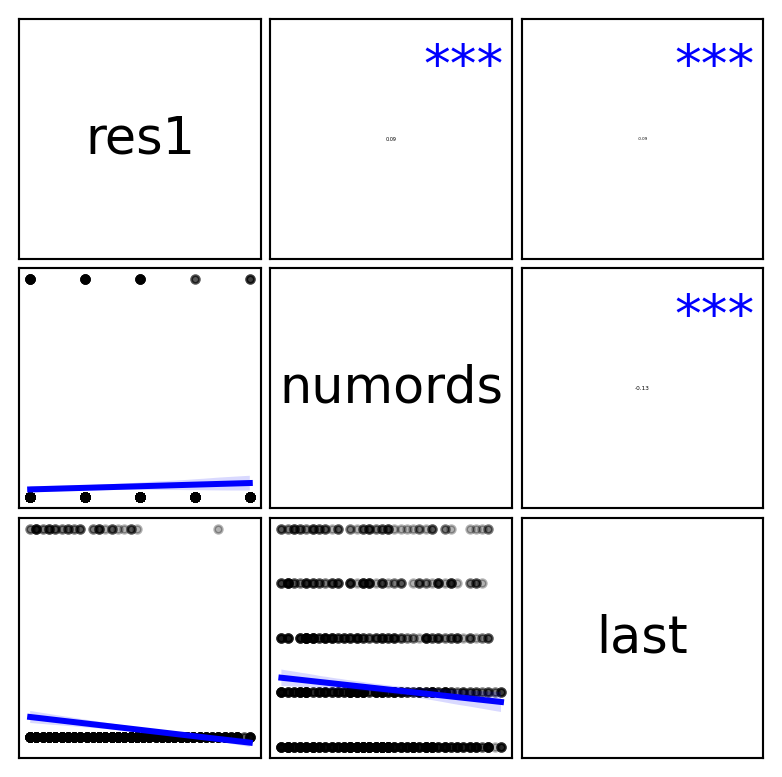

In [21]:
intuit75k_model_v3.plot("corr")

In [22]:
intuit75k_model_v3.summary(main=False, fit=False, vif=True)


Variance inflation factors:



            vif    Rsq
upgraded  1.077  0.071
version1  1.076  0.071
last      1.018  0.017
numords   1.018  0.017
zip_bins  1.001  0.001


Here we are going to test each variable

In [23]:
intuit75k_model_v1.summary(main = False, vif = True, test = "sex")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.114 vs 0.114
Chi-squared: 0.298 df (2), p.value 0.862


Neither the R-squared or AUC changed, thus we conclude that `sex` isn't significant as a variable.

In [24]:
intuit75k_model_v1.summary(main = False, vif = True, test = "numords")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ sex + bizflag + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.107 vs 0.114
Chi-squared: 141.307 df (1), p.value < .001


R-squared changed a bit, thus we conclude that `numords`  should be included in the model.

In [25]:
intuit75k_model_v1.summary(main = False, vif = True, test = "version1")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.110 vs 0.114
Chi-squared: 73.215 df (1), p.value < .001


R-squared changed a bit, thus we conclude that `version1`  should be included in the model.

In [26]:
intuit75k_model_v1.summary(main = False, vif = True, test = "dollars")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + version1 + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.113 vs 0.114
Chi-squared: 15.391 df (1), p.value < .001


Neither the R-squared or AUC changed, thus we conclude that `dollars` isn't significant as a variable.

In [27]:
intuit75k_model_v1.summary(main = False, vif = True, test = "bizflag")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ sex + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.114 vs 0.114
Chi-squared: 0.528 df (1), p.value 0.468


Neither the R-squared or AUC changed, thus we conclude that `bizflag` isn't significant as a variable. and omitted the variable

In [28]:
intuit75k_model_v1.summary(main = False,vif = True, test = "last")


Pseudo R-squared (McFadden): 0.114
Pseudo R-squared (McFadden adjusted): 0.111
Area under the RO Curve (AUC): 0.755
Log-likelihood: -8899.946, AIC: 17859.893, BIC: 18125.95
Chi-squared: 2289.751, df(29), p.value < 0.001 
Nr obs: 52,500

Variance inflation factors:



              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.027
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001
bizflag     1.000  0.000

Model 1: res1 ~ sex + bizflag + numords + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins
Model 2: res1 ~ sex + bizflag + numords + last + sincepurch + owntaxprod + dollars + version1 + upgraded + zip_bins


Pseudo R-squared, Model 1 vs 2: 0.097 vs 0.114
Chi-squared: 350.081 df (1), p.value < .001


R-squared changed significantly, thus we conclude that `last` is significant as a variable.

### We experimented with a neural network to assess whether a more complex model would yield different or improved predictive performance compared to our baseline. We tried a few different variations of hidden layers and alphas. 

#### This allowed us to test for potential non-linear relationships and interactions that traditional models might not capture. By comparing results, we evaluated whether the added complexity provided meaningful gains in accuracy or insights.

In [29]:
clf_nn = rsm.model.mlp(
    
    {'intuit75k':intuit75k},
    hidden_layer_sizes = (5,),
    alpha = .001,
    rvar = "res1",
    lev = "Yes",
    evar = ["zip_bins", "numords", "last", "version1", 'upgraded', 'owntaxprod', 'dollars'],

)

clf_nn.summary()

Multi-layer Perceptron (NN)
Data                 : intuit75k
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, numords, last, version1, upgraded, owntaxprod, dollars
Model type           : classification
Nr. of features      : (7, 25)
Nr. of weights       : 130
Nr. of observations  : 75,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.768

Raw data             :
zip_bins  numords  last version1 upgraded owntaxprod  dollars
      18        2     5        0        0          0    109.5
      10        1     4        0        0          0     69.5
       8        4    14        0        1          0     93.0
       1        1    17        0        0          0     22.0
      11        1     2        0        0          0     24.5

Estimation dat

In [30]:
clf_nn_2 = rsm.model.mlp(
    
    {'intuit75k':intuit75k},
    hidden_layer_sizes = (20,),
    alpha = .20,
    rvar = "res1",
    lev = "Yes",
    evar = ["zip_bins", "numords", "last", "version1", 'upgraded', 'owntaxprod', 'dollars'],

)

clf_nn.summary()

Multi-layer Perceptron (NN)
Data                 : intuit75k
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, numords, last, version1, upgraded, owntaxprod, dollars
Model type           : classification
Nr. of features      : (7, 25)
Nr. of weights       : 130
Nr. of observations  : 75,000
Hidden_layer_sizes   : (5,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.768

Raw data             :
zip_bins  numords  last version1 upgraded owntaxprod  dollars
      18        2     5        0        0          0    109.5
      10        1     4        0        0          0     69.5
       8        4    14        0        1          0     93.0
       1        1    17        0        0          0     22.0
      11        1     2        0        0          0     24.5

Estimation dat

In [31]:
clf_nn = rsm.model.mlp(
    
    {'intuit75k':intuit75k},
    hidden_layer_sizes = (40,),
    alpha = .99,
    rvar = "res1",
    lev = "Yes",
    evar = ["numords", "version1", "upgraded", "last", "sincepurch", "zip_bins"],

)

clf_nn.summary()

Multi-layer Perceptron (NN)
Data                 : intuit75k
Response variable    : res1
Level                : Yes
Explanatory variables: numords, version1, upgraded, last, sincepurch, zip_bins
Model type           : classification
Nr. of features      : (6, 24)
Nr. of weights       : 1,000
Nr. of observations  : 75,000
Hidden_layer_sizes   : (40,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.99
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.803

Raw data             :
 numords version1 upgraded  last  sincepurch zip_bins
       2        0        0     5          12       18
       1        0        0     4           3       10
       4        0        1    14          29        8
       1        0        0    17           1        1
       1        0        0     2           3       11

Estimation data      :
  numords      last  sincepurch  version1_1  u

### Including bizflag in the model as opposed to leaving it out does not impact the model either way. It is indifferent. With that being said, we will leave it out of the model. 

#### Even though `sincepurch` is not significant we decided to include it. The more time since purchase means someone will have old software and may be looking to upgrade

##### We noticed that the odds ratio does not vary between our base model and final model, thus showing little to no interaction. 

#### Interactions: Why It Might Be Important
 - bizflag × zip_bin: Some geographic areas may have higher business density, affecting response rates.
 - sex × bizflag: Male and female business owners may behave differently in upgrading software.
 - version1 × upgraded: If someone upgraded from v1 to v2, they may be more likely to upgrade to v3.
 - numords × dollars: Businesses with many purchases and high spending may be the best upgrade targets.
 - sincepurch × last: Customers who bought software long ago but recently engaged may be at peak upgrade potential.

In [32]:
final_model = rsm.model.logistic(
    data = intuit75k[(intuit75k.training == 1)],
    rvar = "res1",
    lev = "Yes",
    evar = ["numords", "version1", "upgraded", "last", "sincepurch", "zip_bins"],
)
final_model.summary(vif = True)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: numords, version1, upgraded, last, sincepurch, zip_bins
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                 OR     OR%  coefficient  std.error  z.value p.value     
Intercept     0.181  -81.9%        -1.71      0.082  -20.864  < .001  ***
version1[1]   2.081  108.1%         0.73      0.087    8.426  < .001  ***
upgraded[1]   2.636  163.6%         0.97      0.086   11.310  < .001  ***
zip_bins[2]   0.148  -85.2%        -1.91      0.110  -17.314  < .001  ***
zip_bins[3]   0.118  -88.2%        -2.14      0.121  -17.689  < .001  ***
zip_bins[4]   0.137  -86.3%        -1.99      0.112  -17.766  < .001  ***
zip_bins[5]   0.117  -88.3%        -2.14      0.120  -17.848  < .001  ***
zip_bins[6]   0.127  -87.3%        -2.06      0.114  -18.015  < .001  ***
zip_bins[7]   0.123  -87.7%        -2.10      0.117


              vif    Rsq
sincepurch  3.737  0.732
version1    2.968  0.663
upgraded    2.913  0.657
last        1.018  0.017
numords     1.018  0.017
zip_bins    1.001  0.001


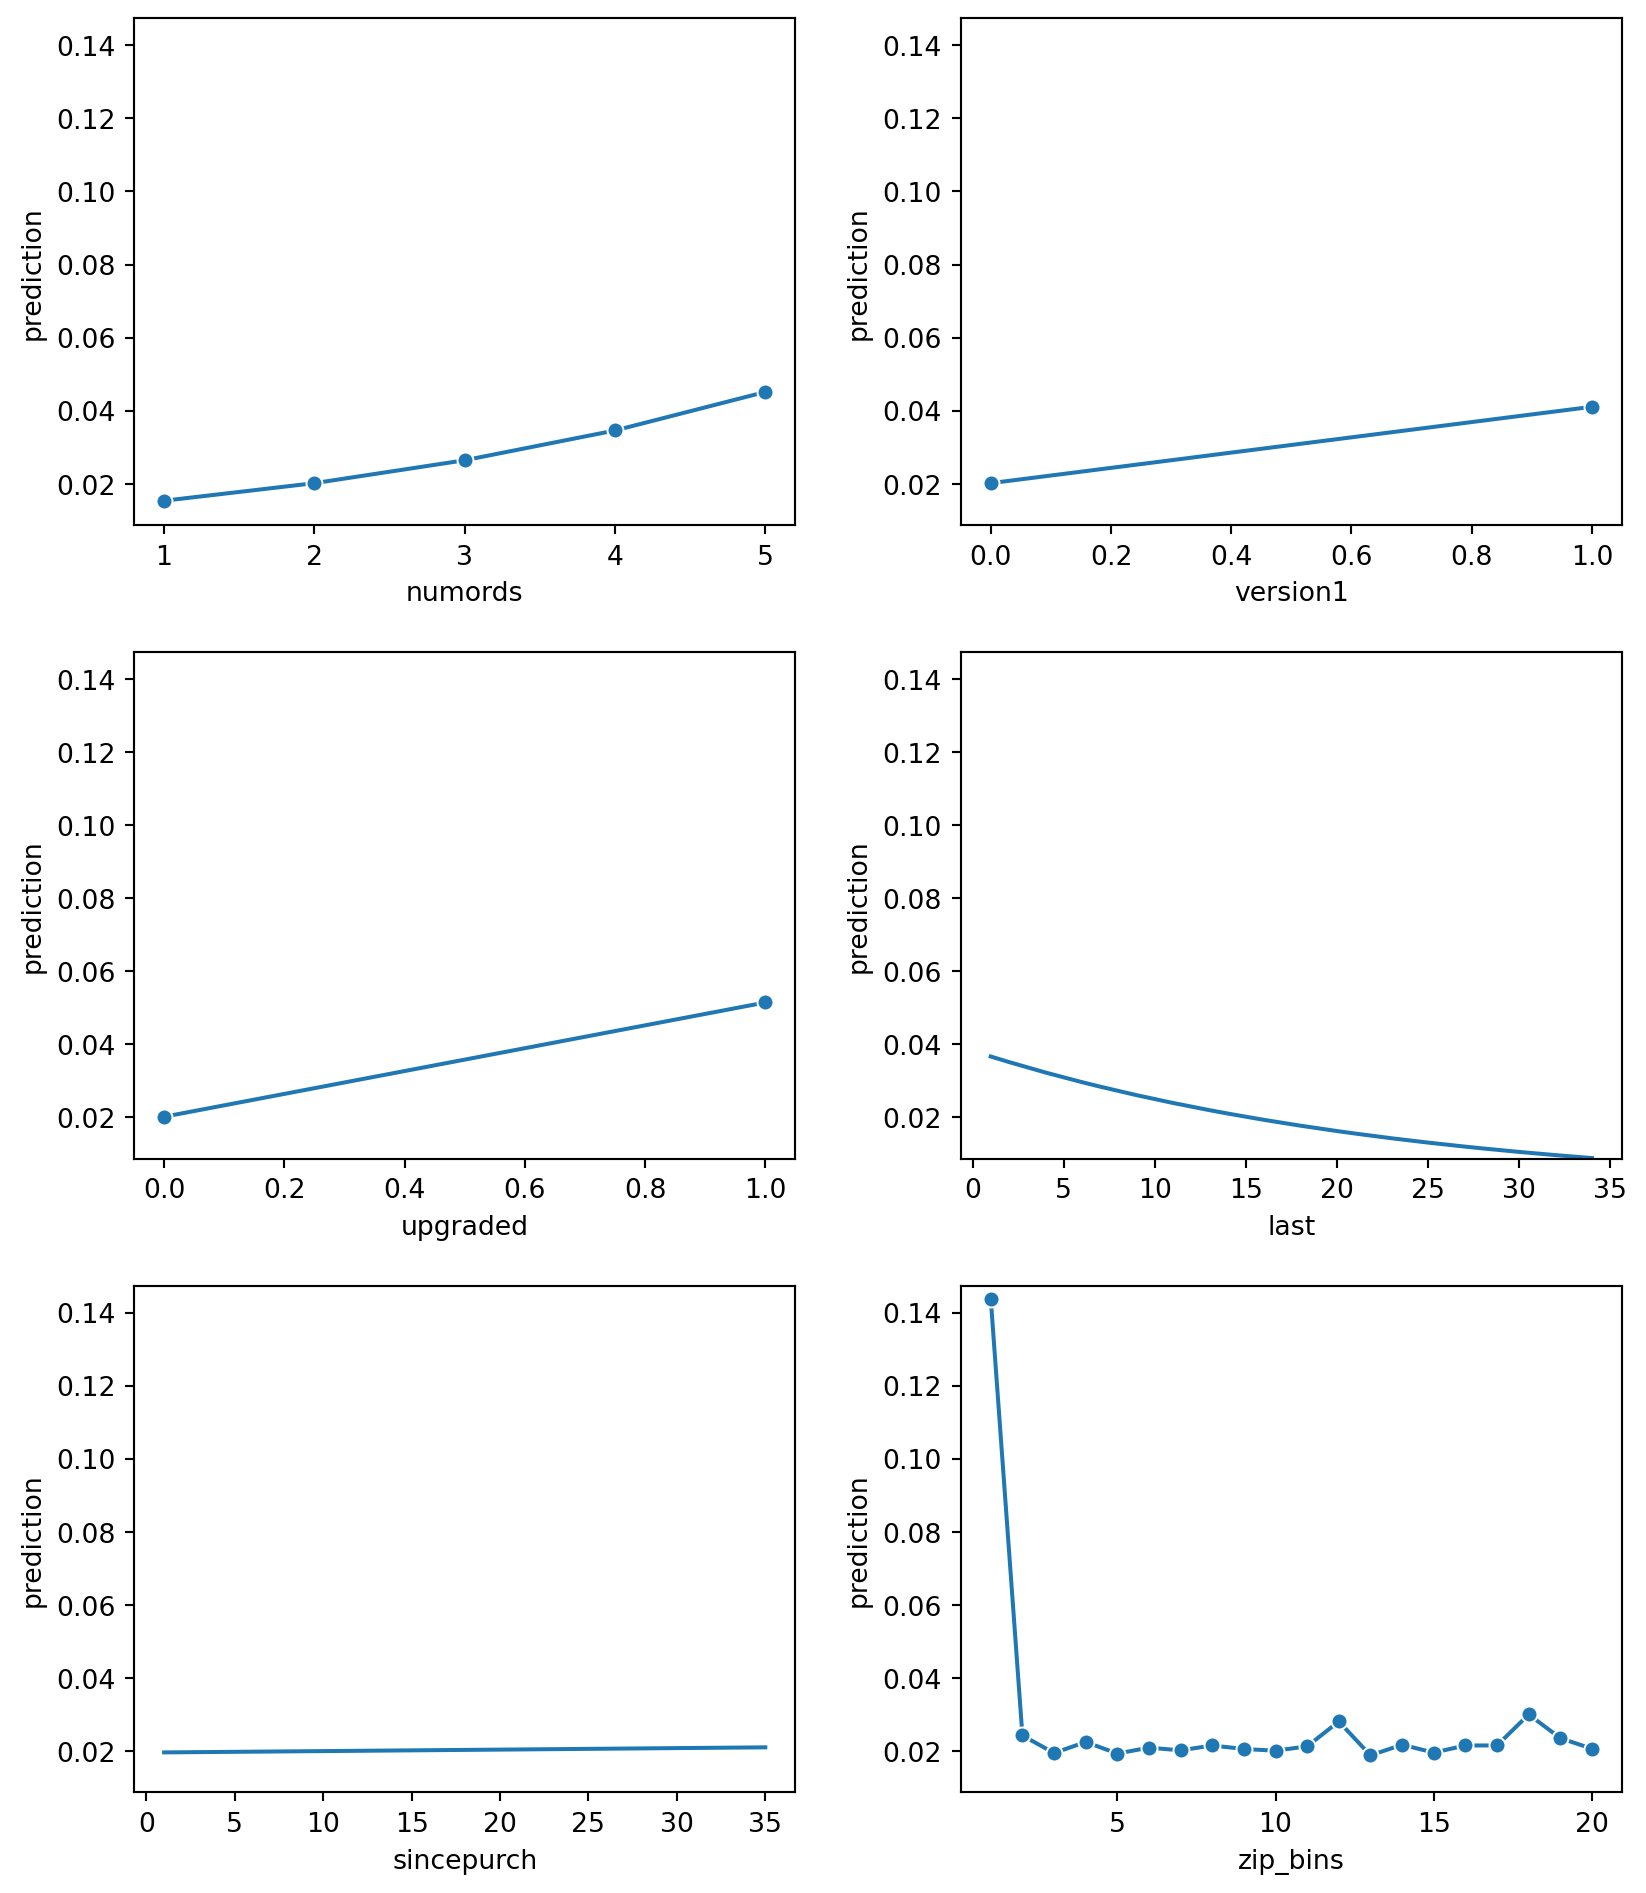

In [33]:
final_model.plot("pred")

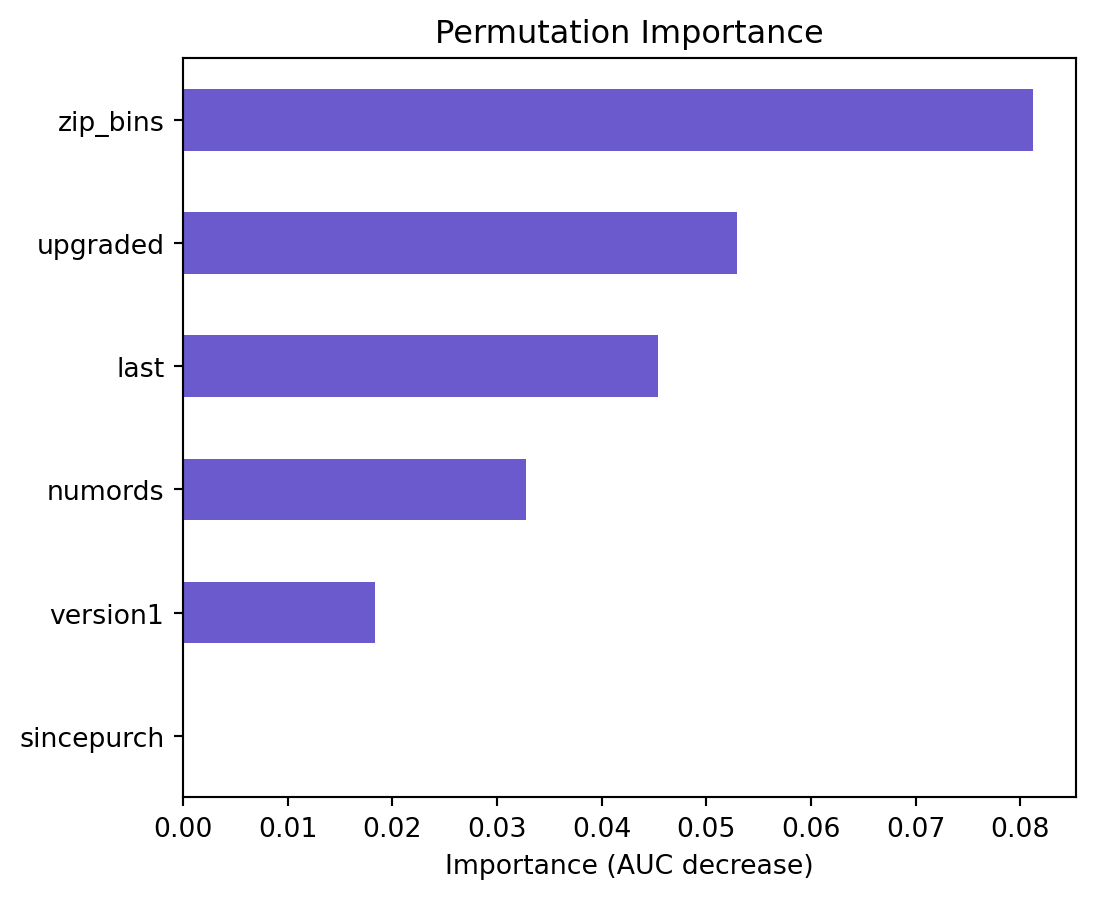

In [34]:
final_model.plot("vimp")

Now that we have our model, let's predict the test data and evaluate the model.

In [35]:
intuit75k["pred_logit"] = final_model.predict(data=intuit75k)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045501
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023960
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.097769
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.101751
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.027635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.054509
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.020635
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.047038
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033899


In [36]:
cost = 1.41
margin = 60.0 

breakeven = cost / margin
breakeven

0.0235

Only target those who are above the breakeven

In [37]:
intuit75k["message_logit"] = intuit75k['pred_logit'] > breakeven

In [38]:
intuit75k.message_logit.value_counts()

message_logit
True     47742
False    27258
Name: count, dtype: int64

In [39]:
intuit75k_test = intuit75k[(intuit75k.training == 0)]
intuit75k_test

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023960,True
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.097769,True
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.027635,True
6,7,22980,5,Male,0,1,49.5,13,36,1,0,0,No,0,0,0.034151,True
8,9,34950,8,Male,0,1,44.5,15,4,0,0,0,No,0,0,0.016013,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74981,74982,90803,16,Male,1,1,129.5,12,16,0,0,0,No,0,0,0.018676,False
74982,74983,71446,12,Male,0,2,22.0,25,1,0,0,0,No,0,0,0.017766,False
74987,74988,80501,15,Female,0,4,94.5,7,23,1,0,0,No,0,0,0.094453,True
74993,74994,40223,8,Female,0,5,170.5,9,20,0,0,1,Yes,0,1,0.148813,True


In [40]:
intuit75k_test.shape[0]

22500

In [41]:
targeted_id =  intuit75k_test[(intuit75k_test.message_logit == True)]
targeted_id

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023960,True
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.097769,True
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.027635,True
6,7,22980,5,Male,0,1,49.5,13,36,1,0,0,No,0,0,0.034151,True
11,12,91942,17,Male,1,5,79.0,5,21,0,0,1,Yes,0,1,0.172819,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74976,74977,92667,17,Female,1,2,185.5,4,11,0,0,0,No,0,0,0.034121,True
74979,74980,98022,20,Male,1,1,24.5,3,31,1,0,0,No,0,0,0.054895,True
74987,74988,80501,15,Female,0,4,94.5,7,23,1,0,0,No,0,0,0.094453,True
74993,74994,40223,8,Female,0,5,170.5,9,20,0,0,1,Yes,0,1,0.148813,True


In [42]:
intuit75k_test.res1.value_counts()

res1
No     21397
Yes     1103
Name: count, dtype: int64

In [43]:
revenue = 1103 * 60
cost = 1103 * 1.41 
profit = revenue - cost
ROME = profit / cost

Confusion matrix:

In [44]:
True_Positive = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["message_logit"] == True)).sum()
False_Positive = ((intuit75k_test["res1"] == "No") & (intuit75k_test["message_logit"] == True)).sum()
True_Negative = ((intuit75k_test["res1"] == "No") & (intuit75k_test["message_logit"] == False)).sum()
False_Negative = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["message_logit"] == False)).sum()

cm_logit = pd.DataFrame(
    {
        "label": ["True_Positive", "False_Positive", "True_Negative", "False_Negative"],
        "nr": [True_Positive, False_Positive, True_Negative, False_Negative] # TP, FP, TN, and FN values in that order
    }
)
cm_logit

,label,nr
0,True_Positive,976
1,False_Positive,13427
2,True_Negative,7970
3,False_Negative,127


In [45]:
accuracy_logit = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative) # float

print(accuracy_logit)

0.3976


In [46]:
cm_logit

,label,nr
0,True_Positive,976
1,False_Positive,13427
2,True_Negative,7970
3,False_Negative,127


We decided not to move forward with Model 1 or Model 2 despite those models having a slightly higher accuracy. We feel that our final model best portrays consumer behavior. 

In [47]:
801821 - 38487

763334

In [48]:
rate = intuit75k_test.res1_yes.mean()
rate

0.049022222222222224

In [49]:
# logit
exp_click_log = 763334 * (976/22500)
#exp_signup_log = exp_click_log * rate
exp_rev_log = exp_click_log * 60

marketing_cost_log = ((763334 * (976/22500)) + (763334 * (13427/22500))) * 1.41
profit_log = exp_rev_log - marketing_cost_log
ROME_log = profit_log / marketing_cost_log

print(exp_click_log)
print(exp_rev_log)
print(marketing_cost_log)
print(f"Profit: {profit_log}")
print(f"ROME: {ROME_log}")

33111.732622222225
1986703.9573333336
688976.108392
Profit: 1297727.8489413336
ROME: 1.883560014831426


In [50]:
# spam

ctr_all = intuit75k_test["res1_yes"].mean()


exp_click_spam = 763334 * ctr_all
#exp_signup_log = exp_click_log * rate
exp_rev_spam = exp_click_spam * 60

marketing_cost_spam = 763334 * 1.41
profit_spam = exp_rev_spam - marketing_cost_spam
ROME_spam = profit_spam / marketing_cost_spam

print(exp_click_spam)
print(exp_rev_spam)
print(marketing_cost_spam)
print(f"Profit: {profit_spam}")
print(f"ROME: {ROME_spam}")

37420.32897777778
2245219.738666667
1076300.94
Profit: 1168918.7986666672
ROME: 1.0860520094562653


In [51]:
mod_perf_profit = pd.DataFrame(
    {
        "model": [
            "logit",
            "spam",
        ],
        "profit": [profit_log,profit_spam],
    }
)

In [52]:
mod_perf_rome = pd.DataFrame(
    {
        "model": [
            "logit",
            "spam",
        ],
        "ROME": [ROME_log,ROME_spam],
    }
)

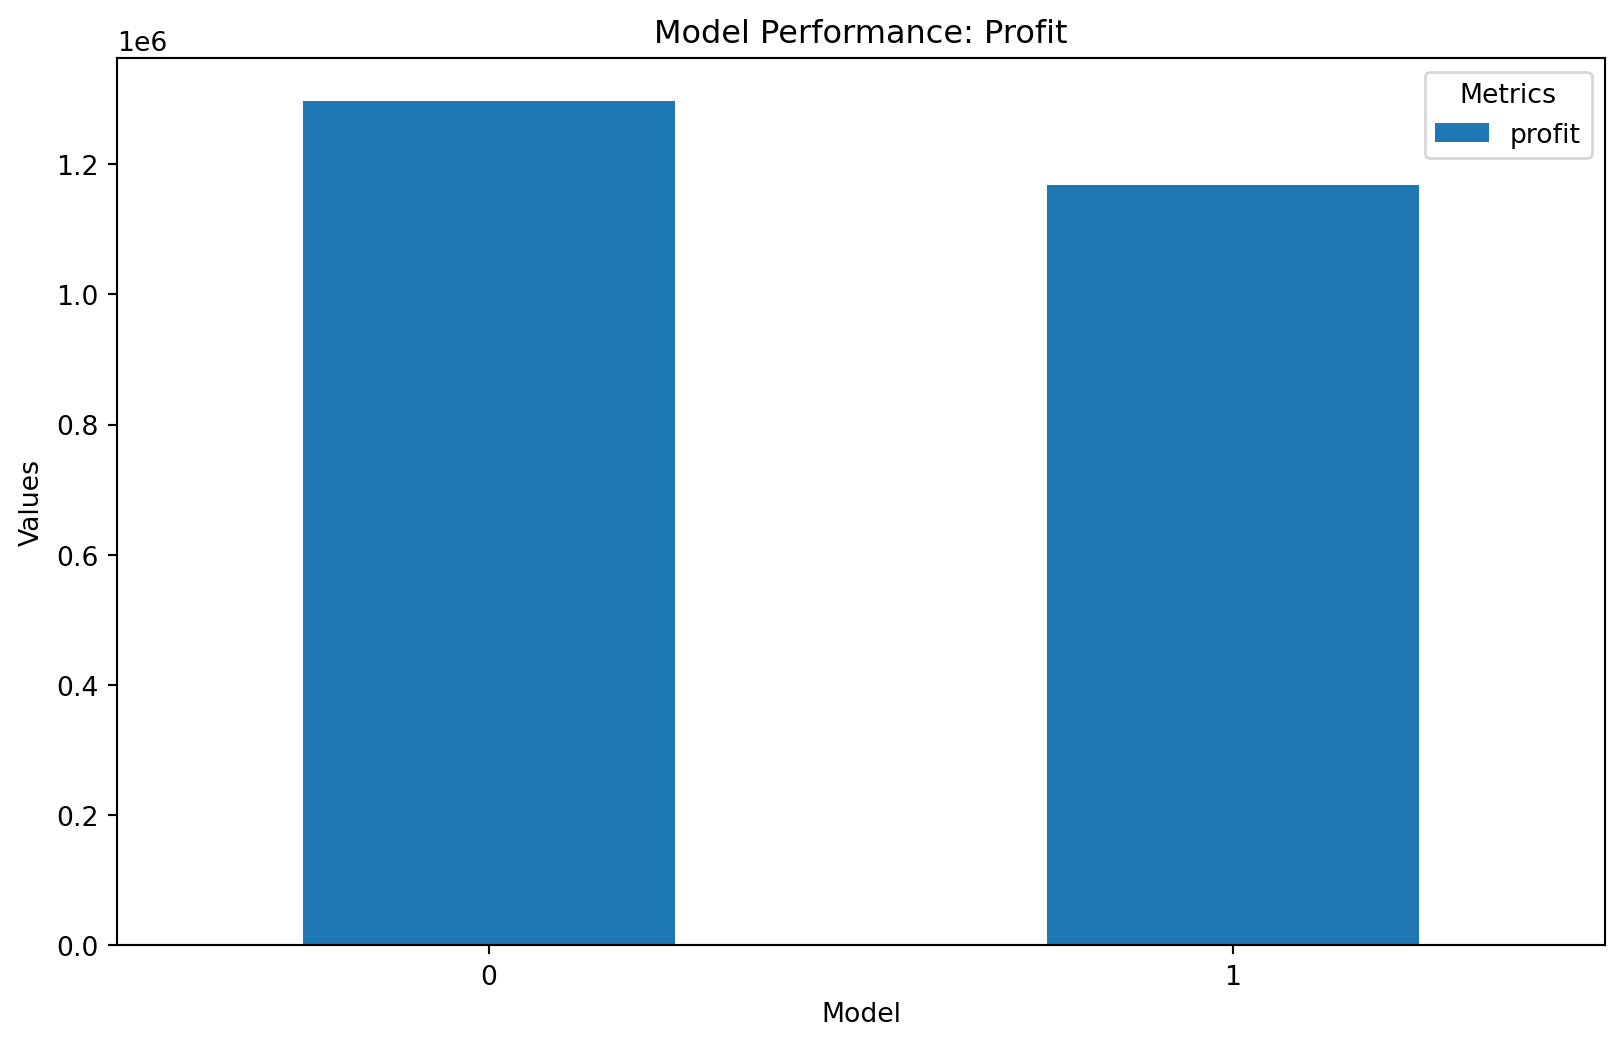

In [53]:
# Set 'model' as the index for better plotting
#mod_perf.set_index("model", inplace=True)

# Plotting both 'profit' and 'ROME'
mod_perf_profit.plot(kind="bar", figsize=(10, 6))

# Customizing plot
plt.title("Model Performance: Profit")
plt.xlabel("Model")
plt.ylabel("Values")
plt.legend(title="Metrics")
plt.xticks(rotation=0)  # Keep model labels readable

# Show the plot
plt.show()

### As we can see on the above graph, predicted model have higher profit than the spam model.

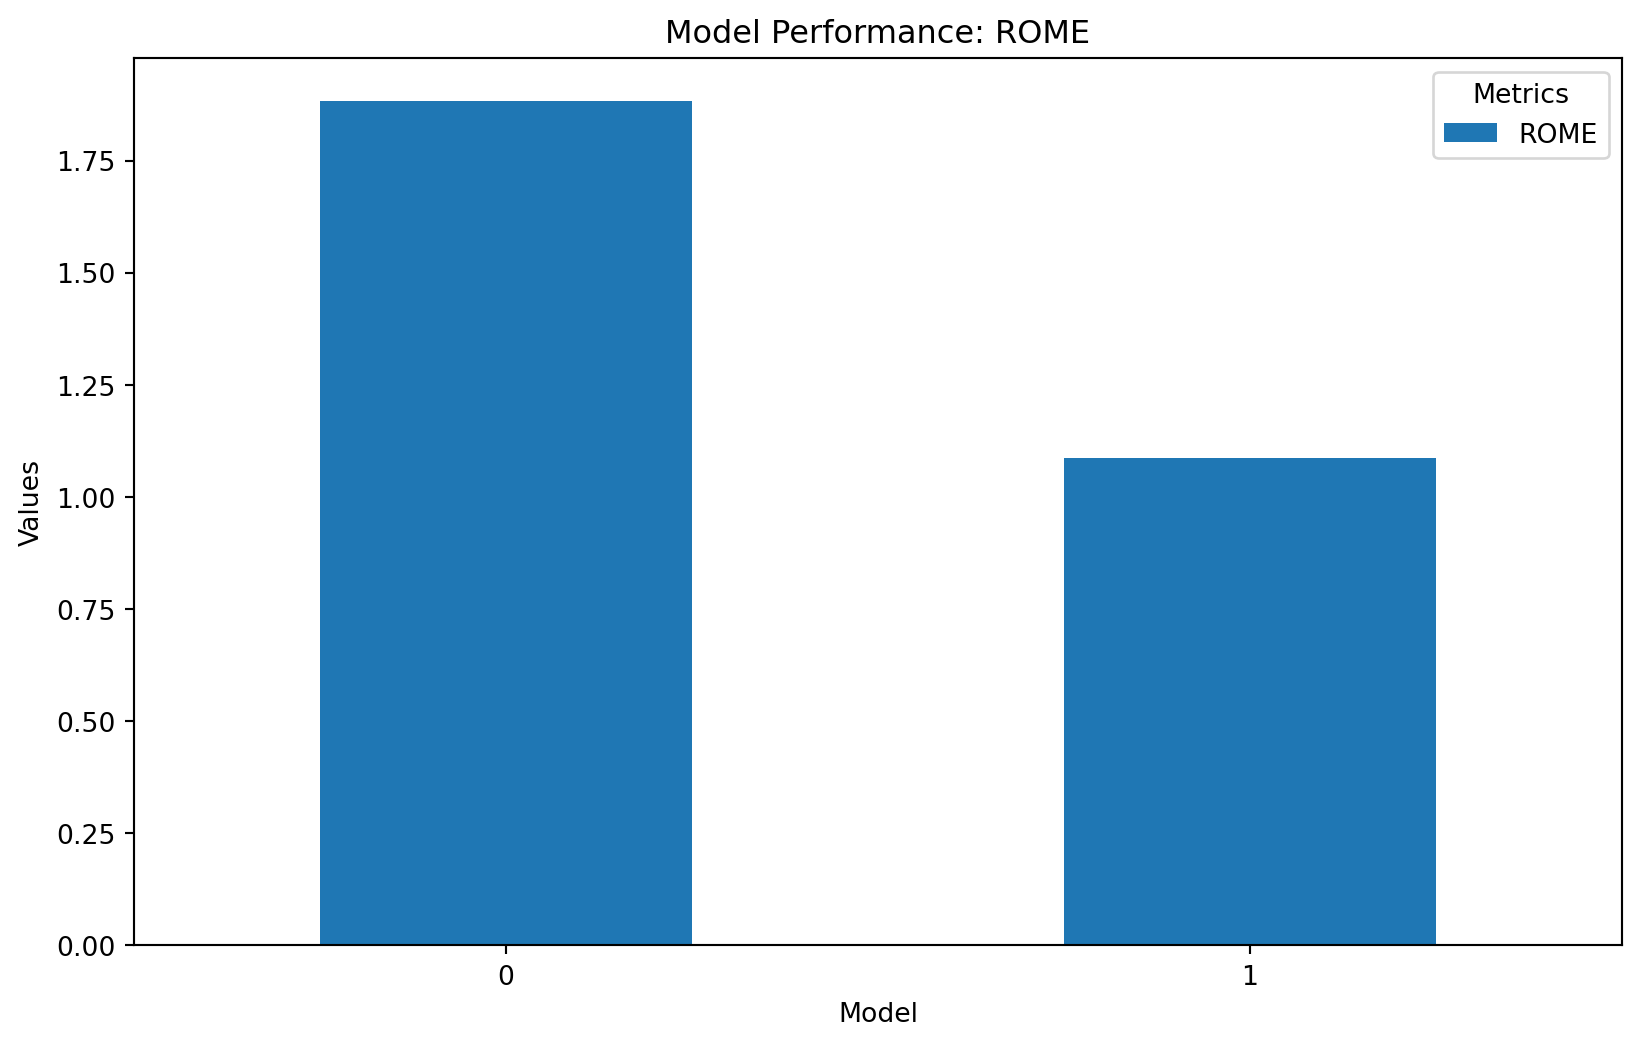

In [54]:
# Set 'model' as the index for better plotting
#mod_perf.set_index("model", inplace=True)

# Plotting both 'profit' and 'ROME'
mod_perf_rome.plot(kind="bar", figsize=(10, 6))

# Customizing plot
plt.title("Model Performance: ROME")
plt.xlabel("Model")
plt.ylabel("Values")
plt.legend(title="Metrics")
plt.xticks(rotation=0)  # Keep model labels readable

# Show the plot
plt.show()

### As we can see on the above graph, predicted model have higher rome than the spam model.

# Question 4 - 50% drop off in response from wave-1 to wave-2

In [55]:
# Randomly drop 50% of values from "drop_pred_logit"
np.random.seed(42)  # For reproducibility
intuit75k_test.loc[
    np.random.choice(intuit75k_test.index, size=len(intuit75k_test) // 2, replace=False),
    "drop_pred_logit"
] = np.nan

/tmp/ipykernel_16300/1905171041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intuit75k_test.loc[


In [56]:
intuit75k_test

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit,drop_pred_logit
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023960,True,NaN
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.097769,True,NaN
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.027635,True,NaN
6,7,22980,5,Male,0,1,49.5,13,36,1,0,0,No,0,0,0.034151,True,NaN
8,9,34950,8,Male,0,1,44.5,15,4,0,0,0,No,0,0,0.016013,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74981,74982,90803,16,Male,1,1,129.5,12,16,0,0,0,No,0,0,0.018676,False,NaN
74982,74983,71446,12,Male,0,2,22.0,25,1,0,0,0,No,0,0,0.017766,False,NaN
74987,74988,80501,15,Female,0,4,94.5,7,23,1,0,0,No,0,0,0.094453,True,NaN
74993,74994,40223,8,Female,0,5,170.5,9,20,0,0,1,Yes,0,1,0.148813,True,NaN


In [57]:

intuit75k_test["drop_message_logit"] = intuit75k_test["drop_pred_logit"] > breakeven 

/tmp/ipykernel_16300/5424778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intuit75k_test["drop_message_logit"] = intuit75k_test["drop_pred_logit"] > breakeven


In [58]:
True_Positive = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["drop_message_logit"] == True)).sum()
False_Positive = ((intuit75k_test["res1"] == "No") & (intuit75k_test["drop_message_logit"] == True)).sum()
True_Negative = ((intuit75k_test["res1"] == "No") & (intuit75k_test["drop_message_logit"] == False)).sum()
False_Negative = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["drop_message_logit"] == False)).sum()

cm_logit = pd.DataFrame(
    {
        "label": ["True_Positive", "False_Positive", "True_Negative", "False_Negative"],
        "nr": [True_Positive, False_Positive, True_Negative, False_Negative] # TP, FP, TN, and FN values in that order
    }
)
cm_logit

,label,nr
0,True_Positive,0
1,False_Positive,0
2,True_Negative,21397
3,False_Negative,1103


In [59]:
# logit
exp_click_log = 763334 * (460/22500)

exp_rev_log = exp_click_log * 60

marketing_cost_log = ((763334 * (460/22500)) + (763334 * (6752/22500))) * 1.41
profit_log = exp_rev_log - marketing_cost_log
ROME_log = profit_log / marketing_cost_log

print(exp_click_log)
print(exp_rev_log)
print(marketing_cost_log)
print(f"Profit: {profit_log}")
print(f"ROME: {ROME_log}")

15605.939555555557
936356.3733333334
344990.327968
Profit: 591366.0453653333
ROME: 1.7141525353724878


### We can see that dropping the response rate to 50% will result in a loss of profit.

## Assumptions + interpretation of variables

Zip_bins : Certain zip bins (e.g., Bin 1, Bin 12, Bin 18) have higher response rates. Zip bins may indicate regional factors that influence purchasing behavior like cities may be more likely to upgrade than small towns. This suggests that zip_bins is a strong predictive feature and should be included in the model.

Numords: More past orders indicate a higher likelihood of responding. This may be due to higher engagement and more engagement may mean more likely to be a repeat customer.

Sex: Gender is split about 60 / 30 / 10 for male / female / unknown respectively. Hinting that gender is a variable to account for. Historically there has been a larger pool of software customers that are male as opposed to other gender, aligning with our preliminary results. If male/female business owners behave differently, this might be a significant interaction with bizflag.

Version1: Customers on version 1 may need an upgrade more than version 2 users as their software is more outdated. The version1 user may have a higher response rate than version 2 as it is older.

Owntaxprod: If the user has previously purchased the software, they are likely to purchase more in the future. Customers using tax products might be loyal to Intuit, leading to higher upgrade likelihood.

Sincepurch: This variable represents the time since the customer originally purchased Quickbooks. This is a key predictor of response likelihood because it reflects customer lifecycle and engagement Customers who purchased a long time ago may be due for an upgrade.Older customers may either be loyal users or satisfied non-upgraders. 

Upgraded: Customers who have upgraded their software before are more likely to do so again. They might be willing to upgrade to a newer version as they are familiar with the software and may be loyal to it 

Last: Customers who have purchased recently or at a regular cadence are more likely to purchase again than those who have not purchased in a while. We saw this trend with our previous case studies and thus expect it to hold true here as well (at least until disproved).

We change the integer variables (version1, owntaxprod, upgraded) that had values of 0 and 1 to factors as those variables are not continuous. It does not make sense to have it be integers

## Model 1

In [60]:
intuit75k_model_v6 = rsm.model.logistic(
    data=intuit75k.query("training == 1"),
    rvar="res1",
    lev="Yes",
    evar=["numords", "version1", "upgraded", "last", "zip_bins",  "owntaxprod", "dollars", 'sincepurch'],
    # ivar = ["last: zip_bins"],
)
intuit75k_model_v6.summary(vif = True,)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: numords, version1, upgraded, last, zip_bins, owntaxprod, dollars, sincepurch
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                  OR     OR%  coefficient  std.error  z.value p.value     
Intercept      0.178  -82.2%        -1.72      0.082  -20.992  < .001  ***
version1[1]    2.112  111.2%         0.75      0.087    8.580  < .001  ***
upgraded[1]    2.615  161.5%         0.96      0.086   11.198  < .001  ***
zip_bins[2]    0.148  -85.2%        -1.91      0.110  -17.299  < .001  ***
zip_bins[3]    0.118  -88.2%        -2.14      0.121  -17.708  < .001  ***
zip_bins[4]    0.136  -86.4%        -2.00      0.112  -17.806  < .001  ***
zip_bins[5]    0.116  -88.4%        -2.15      0.120  -17.893  < .001  ***
zip_bins[6]    0.126  -87.4%        -2.07      0.115  -18.044  < .001  ***
zip_bins[7]    0.121 


              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.026
last        1.018  0.017
zip_bins    1.002  0.002


In [61]:
intuit75k["pred_logit"] = intuit75k_model_v6.predict(data=intuit75k)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045754,True
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.024226,True
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.088417,True
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.098746,True
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026569,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.055721,True
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.019716,False
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.047320,True
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033969,True


In [62]:
cost = 1.41
margin = 60.0 

breakeven = cost / margin
breakeven

0.0235

In [63]:
intuit75k["message_logit"] = intuit75k['pred_logit'] > breakeven

In [64]:
intuit75k.message_logit.value_counts()

message_logit
True     47490
False    27510
Name: count, dtype: int64

In [65]:
intuit75k_test = intuit75k[(intuit75k.training == 0)]
intuit75k_test

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.024226,True
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.088417,True
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026569,True
6,7,22980,5,Male,0,1,49.5,13,36,1,0,0,No,0,0,0.034082,True
8,9,34950,8,Male,0,1,44.5,15,4,0,0,0,No,0,0,0.015861,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74981,74982,90803,16,Male,1,1,129.5,12,16,0,0,0,No,0,0,0.020083,False
74982,74983,71446,12,Male,0,2,22.0,25,1,0,0,0,No,0,0,0.016403,False
74987,74988,80501,15,Female,0,4,94.5,7,23,1,0,0,No,0,0,0.086971,True
74993,74994,40223,8,Female,0,5,170.5,9,20,0,0,1,Yes,0,1,0.139861,True


In [66]:
True_Positive = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["message_logit"] == True)).sum()
False_Positive = ((intuit75k_test["res1"] == "No") & (intuit75k_test["message_logit"] == True)).sum()
True_Negative = ((intuit75k_test["res1"] == "No") & (intuit75k_test["message_logit"] == False)).sum()
False_Negative = ((intuit75k_test["res1"] == "Yes") & (intuit75k_test["message_logit"] == False)).sum()


In [67]:
cm_logit = pd.DataFrame(
    {
        "label": ["True_Positive", "False_Positive", "True_Negative", "False_Negative"],
        "nr": [True_Positive, False_Positive, True_Negative, False_Negative] # TP, FP, TN, and FN values in that order
    }
)
cm_logit

,label,nr
0,True_Positive,980
1,False_Positive,13335
2,True_Negative,8062
3,False_Negative,123


In [68]:
accuracy_logit = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative) # float

print(accuracy_logit)

0.40186666666666665


## Model 2

In [69]:
intuit75k_model_v7 = rsm.model.logistic(
    data=intuit75k.query("training == 1"),
    rvar="res1",
    lev="Yes",
    evar=["numords", "version1", "upgraded", "last", "zip_bins", "owntaxprod", "sex", "dollars", 'sincepurch'],
   
)
intuit75k_model_v7.summary(vif = True,)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : res1
Level                : Yes
Explanatory variables: numords, version1, upgraded, last, zip_bins, owntaxprod, sex, dollars, sincepurch
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                  OR     OR%  coefficient  std.error  z.value p.value     
Intercept      0.182  -81.8%        -1.70      0.092  -18.574  < .001  ***
version1[1]    2.111  111.1%         0.75      0.087    8.578  < .001  ***
upgraded[1]    2.616  161.6%         0.96      0.086   11.199  < .001  ***
zip_bins[2]    0.148  -85.2%        -1.91      0.110  -17.299  < .001  ***
zip_bins[3]    0.117  -88.3%        -2.14      0.121  -17.713  < .001  ***
zip_bins[4]    0.136  -86.4%        -2.00      0.112  -17.809  < .001  ***
zip_bins[5]    0.116  -88.4%        -2.15      0.120  -17.896  < .001  ***
zip_bins[6]    0.126  -87.4%        -2.07      0.115  -18.047  < .001  ***
zip_bins[7]    0


              vif    Rsq
sincepurch  3.737  0.732
version1    2.972  0.664
upgraded    2.919  0.657
numords     1.558  0.358
dollars     1.527  0.345
owntaxprod  1.027  0.026
last        1.018  0.017
zip_bins    1.003  0.003
sex         1.001  0.001


In [70]:
intuit75k["pred_logit_2"] = intuit75k_model_v7.predict(data=intuit75k)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit,pred_logit_2
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045754,True,0.045583
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.024226,True,0.023849
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.088417,True,0.088133
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.098746,True,0.098437
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026569,True,0.026462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.055721,True,0.055514
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.019716,False,0.019648
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.047320,True,0.048264
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033969,True,0.033849


In [71]:
intuit75k["message_logit_2"] = intuit75k['pred_logit_2'] > breakeven

In [72]:
intuit75k.message_logit_2.value_counts()

message_logit_2
True     47501
False    27499
Name: count, dtype: int64

In [73]:
intuit75k_test_2 = intuit75k[(intuit75k.training == 0)]
intuit75k_test_2

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,message_logit,pred_logit_2,message_logit_2
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.024226,True,0.023849,True
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.088417,True,0.088133,True
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026569,True,0.026462,True
6,7,22980,5,Male,0,1,49.5,13,36,1,0,0,No,0,0,0.034082,True,0.033949,True
8,9,34950,8,Male,0,1,44.5,15,4,0,0,0,No,0,0,0.015861,False,0.015800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74981,74982,90803,16,Male,1,1,129.5,12,16,0,0,0,No,0,0,0.020083,False,0.019999,False
74982,74983,71446,12,Male,0,2,22.0,25,1,0,0,0,No,0,0,0.016403,False,0.016343,False
74987,74988,80501,15,Female,0,4,94.5,7,23,1,0,0,No,0,0,0.086971,True,0.088678,True
74993,74994,40223,8,Female,0,5,170.5,9,20,0,0,1,Yes,0,1,0.139861,True,0.142432,True


In [74]:
True_Positive = ((intuit75k_test_2["res1"] == "Yes") & (intuit75k_test_2["message_logit_2"] == True)).sum()
False_Positive = ((intuit75k_test_2["res1"] == "No") & (intuit75k_test_2["message_logit_2"] == True)).sum()
True_Negative = ((intuit75k_test_2["res1"] == "No") & (intuit75k_test_2["message_logit_2"] == False)).sum()
False_Negative = ((intuit75k_test_2["res1"] == "Yes") & (intuit75k_test_2["message_logit_2"] == False)).sum()


In [75]:
cm_logit = pd.DataFrame(
    {
        "label": ["True_Positive", "False_Positive", "True_Negative", "False_Negative"],
        "nr": [True_Positive, False_Positive, True_Negative, False_Negative] # TP, FP, TN, and FN values in that order
    }
)
cm_logit

,label,nr
0,True_Positive,980
1,False_Positive,13326
2,True_Negative,8071
3,False_Negative,123


In [76]:
accuracy_logit = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative) # float

print(accuracy_logit)

0.40226666666666666


## Model 3

After trying a few different ways - we felt that the final model is still better. We noticed that the accuracy did not change much between model 1 and 2. 

## Explicit Answers to Question + Conclusion

Businesses with More Orders (numords) Are More Likely to Upgrade

More Recent Buyers (last) Are More Likely to Upgrade

Businesses in Certain Locations (zip_bins) Upgrade More - Zip_bins 1, 12, 18

Older Version Users (version1) Are More Likely to Upgrade

 Businesses That Have Upgraded Before (upgraded) Are More Likely to Upgrade Again